# 출시 전 LLM 리뷰 분석 보고서: Action 장르

## 분석 목적

이 보고서는 `Action` 장르와 유사한 Steam 인디게임의 출시 초기 리뷰를 LLM으로 분석하여, 개발자가 출시 전 단계에서 **유저들이 어떤 요소를 긍정적으로 평가하고, 어떤 요소에 불만을 가지는지** 파악하는 것을 목적으로 한다.

이번 보고서에서는 **v2 결과**를 최종 기준으로 사용한다.  
리뷰 수를 더 늘린 v3 결과도 있었지만, 일부 게임의 비중이 커지는 문제가 있어 장르 단위 분석에는 v2가 더 적합하다고 판단하였다.

## 핵심 질문

1. Action 장르 유저들은 어떤 요소를 긍정적으로 평가하는가?
2. Action 장르 유저들은 어떤 요소에 불만을 가지는가?
3. 가격대, Steam 태그, 플레이 방식에 따라 이슈가 달라지는가?
4. 출시 전 단계에서 우선적으로 점검해야 할 리스크는 무엇인가?
5. 이 결과를 출시 전 체크리스트와 개발 우선순위로 어떻게 연결할 수 있는가?

# 1. 설정값

아래 설정값은 `03-1_run_llm_sentiment_Action_PreLaunch_v2.ipynb`에서 생성한 LLM 분석 결과를 불러오기 위한 경로 설정이다.

다른 환경에서 실행할 경우 `ROOT`만 본인 프로젝트 경로에 맞게 수정하면 된다.  
LLM 분석 결과 파일은 `data/outputs/main_action_d0-d30_1000_v2` 폴더에 있다고 가정한다.

## 최종 사용 기준

| 항목 | 설정값 |
|---|---|
| 분석 장르 | Action |
| 리뷰 구간 | D0-D30 |
| 게임당 최대 리뷰 수 | 100개 |
| 전체 최대 리뷰 수 | 1,000개 |
| 실제 분석 리뷰 수 | 770개 |
| 실제 분석 게임 수 | 28개 |
| 샘플링 방식 | `balanced_by_steam_label` |

v3에서는 전체 리뷰 수가 995개까지 늘어났지만, 상위 일부 게임의 비중이 커졌다.  
따라서 본 보고서에서는 리뷰 수와 게임별 균형을 함께 고려하여 v2 결과를 최종 기준으로 사용한다.


In [1]:
# ============================================================
# 데이터 분석용 라이브러리
# ============================================================
import platform
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


# ============================================================
# 한글 폰트 설정
# ============================================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

In [ ]:
# 프로젝트 루트 직접 지정
# 다른 환경에서 실행할 경우 ROOT만 본인 프로젝트 경로에 맞게 수정합니다.
from pathlib import Path
ROOT = Path(r"C:\Users\joon5\Documents\github\steam-indie-game-analysis")

# ============================================================
# LLM 분석 산출물 폴더
# ============================================================
# 최종 보고서에서는 v2 결과를 사용한다.
# v2는 게임별 최대 100개 리뷰를 기준으로 샘플링한 결과이다.
RUN_NAME = "main_action_d0-d30_1000_v2"
OUTPUT_DIR = ROOT / "data" / "outputs" / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 보고서에 표시할 LLM 실행 설정값
TARGET_GENRE = "Action"
REVIEWS_PER_GAME = 100
MAX_TOTAL_REVIEWS = 1000
SAMPLE_MODE = "balanced_by_steam_label"

# LLM 분석 산출물
RESULT_CSV_PATH = OUTPUT_DIR / "llm_review_analysis_result.csv"
ISSUE_TAG_FLAT_PATH = OUTPUT_DIR / "llm_issue_tags_flat.csv"
LLM_INPUT_PATH = OUTPUT_DIR / "llm_input_reviews.csv"

# 전처리 산출물 후보 경로
# LLM 입력 파일에 메타데이터가 없을 경우를 대비해 사용한다.
PREPROCESS_RUN_NAME = "preprocess_llm"
PREPROCESS_OUTPUT_DIR = ROOT / "data" / "outputs" / PREPROCESS_RUN_NAME

PREPROCESSED_REVIEWS_PATH = PREPROCESS_OUTPUT_DIR / "llm_preprocessed_reviews.csv"


print("\n프로젝트 루트:", ROOT)
print("LLM 분석 결과:", RESULT_CSV_PATH)
print("이슈 태그 결과:", ISSUE_TAG_FLAT_PATH)
print("LLM 입력 리뷰:", LLM_INPUT_PATH)
print("전처리 리뷰 파일 경로:", PREPROCESSED_REVIEWS_PATH)
print("결과 저장 폴더:", OUTPUT_DIR)



프로젝트 루트: C:\Users\joon5\Documents\github\steam-indie-game-analysis
LLM 분석 결과: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0-d30_1000_v2\llm_review_analysis_result.csv
이슈 태그 결과: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0-d30_1000_v2\llm_issue_tags_flat.csv
LLM 입력 리뷰: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0-d30_1000_v2\llm_input_reviews.csv
전처리 리뷰 파일 경로: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\preprocess_llm\llm_preprocessed_reviews.csv
결과 저장 폴더: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0-d30_1000_v2


# 2. 데이터 불러오기 및 기본 점검

출시 전 분석에서 핵심이 되는 데이터는 두 가지다.

| 데이터 | 분석 관점 |
|---|---|
| 리뷰 단위 데이터 | 리뷰별 Steam 라벨, LLM 감정, 주요 이슈, 긴급도 |
| 태그 단위 데이터 | 리뷰 안에서 반복적으로 추출된 칭찬 요인과 불만 요인 |

먼저 결과 파일이 정상적으로 불러와지는지, 분석 리뷰 수와 게임 수가 어느 정도인지 확인한다.

In [3]:
# ============================================================
# 데이터 불러오기
# ============================================================

df_result = pd.read_csv(RESULT_CSV_PATH)
df_tag = pd.read_csv(ISSUE_TAG_FLAT_PATH)
df_META = pd.read_csv(PREPROCESSED_REVIEWS_PATH)

print("LLM 분석 결과 행 수:", len(df_result))
print("이슈 태그 행 수:", len(df_tag))
print("분석 게임 수:", df_result["appid"].nunique())

display(df_result.head())
display(df_tag.head())

LLM 분석 결과 행 수: 770
이슈 태그 행 수: 1552
분석 게임 수: 28


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,sentiment_score,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation
0,success,193552472,1054510,Survivalist: Invisible Strain,2025-04-25 13:52:54,2025-04-25,0.0,D0-D30,positive,63.216667,0.0,0.500000,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'Definitely worth the price. Its a quite uniqu...",low,가격 대비 가치가 높고 독창적인 게임성을 가진 훌륭한 게임임.,"현재의 독창적인 게임성을 유지하며, 향후 업데이트에서도 가격 대비 만족도를 높일 수 있는 콘텐츠를 지속적으로 추가하십시오.",exact_match
1,success,193564502,1054510,Survivalist: Invisible Strain,2025-04-25 17:00:16,2025-04-25,0.0,D0-D30,positive,1006.266667,8.0,0.543334,positive,5.0,gameplay_loop,"[{'category': 'gameplay_loop', 'sentiment': 'positive', 'evidence': 'recruit NPCs to your community and have them do...",low,"NPC 관리 시스템과 좀비 감염 메커니즘이 뛰어나며, 다수 좀비와의 전투 밸런스 조정이 필요함.",NPC 관리 및 좀비 감염 시스템에 대한 유저 만족도가 높음. 다수 좀비와의 전투 밸런스를 검토하여 난이도 조절을 고려하십시오.,exact_match
2,success,193570077,1054510,Survivalist: Invisible Strain,2025-04-25 18:29:43,2025-04-25,0.0,D0-D30,positive,71.483333,0.0,0.500000,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'game I can get lost in for hours'}, {'categor...",low,전략적 깊이가 있고 도전적인 난이도를 가진 몰입감 높은 게임임.,"높은 난이도와 전략적 깊이를 선호하는 유저층이 형성되어 있으므로, 현재의 도전적인 난이도 기조를 유지하십시오.",exact_match
3,success,193578442,1054510,Survivalist: Invisible Strain,2025-04-25 20:45:58,2025-04-25,0.0,D0-D30,positive,5.733333,0.0,0.478548,mixed,4.0,multiplayer_network,"[{'category': 'multiplayer_network', 'sentiment': 'negative', 'evidence': 'only one conversation going at a time, fr...",high,"게임 자체는 매우 훌륭하고 자유도가 높으나, 멀티플레이 시 한 번에 하나의 대화만 가능한 시스템이 협동 플레이를 저해함.","멀티플레이어 환경에서 NPC와의 대화 시스템을 독립적으로 처리할 수 있도록 개선하여, 여러 플레이어가 동시에 각기 다른 NPC와 대화할 수 있는 환경을 구축하세요.",partial_match
4,success,193594348,1054510,Survivalist: Invisible Strain,2025-04-26 02:06:16,2025-04-25,1.0,D0-D30,positive,241.783333,8.0,0.563492,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'best example of a labor of love, fun, hard, a...",low,"전작부터 발전해온 모습이 인상적이며, 장르적 특성을 잘 살린 완성도 높은 게임임.","현재의 게임 방향성을 유지하며, 기존 팬들이 만족하는 깊이 있는 게임플레이 요소를 지속적으로 업데이트하세요.",exact_match


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence
0,193552472,1054510,Survivalist: Invisible Strain,positive,positive,positive_praise,low,D0-D30,63.216667,0.0,0.500000,positive_praise,긍정 칭찬,positive,Definitely worth the price. Its a quite unique game
1,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,gameplay_loop,게임플레이 루프,positive,recruit NPCs to your community and have them do all the tedious stuff
2,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,gameplay_loop,게임플레이 루프,positive,infect your opponents with the zombie virus
3,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,balance,밸런스,neutral,Combat against zombies can be dicey when faced against multiple opponents
4,193570077,1054510,Survivalist: Invisible Strain,positive,positive,positive_praise,low,D0-D30,71.483333,0.0,0.500000,positive_praise,긍정 칭찬,positive,game I can get lost in for hours


## 2-1. 메타데이터 결합

가격대, Steam 태그, 플레이 방식별 비교를 위해 LLM 분석 결과에 전처리 리뷰 파일의 메타데이터를 결합한다.

이번 확장 분석에서 사용하는 기준 컬럼은 다음과 같다.

| 컬럼 | 활용 |
|---|---|
| `price`, `price_group` | 가격대별 이슈 비교 |
| `top_steam_tags_text` | Steam 태그별 이슈 비교 |
| `categories_text` | 플레이 방식 분류 |

이 단계는 LLM 분석을 다시 수행하는 것이 아니라, 이미 생성된 LLM 결과에 게임 속성 정보를 붙여 후속 비교 분석을 가능하게 만드는 단계이다.


In [4]:
# ============================================================
# 2-1. 메타데이터 준비
# ============================================================
# 전처리 리뷰 파일(df_META)에서 게임 단위 메타데이터를 가져온다.
# appid 기준으로 중복을 제거하여 df_result, df_tag에 결합한다.

meta_cols = [
    "appid",
    "price",
    "price_group",
    "top_steam_tags_text",
    "categories_text",
]

df_meta = df_META[meta_cols].copy()

# appid 기준 중복 제거
# 같은 게임의 리뷰가 여러 개 있으므로, 게임 메타데이터는 appid 기준으로 1개만 남긴다.
df_meta = df_meta.drop_duplicates("appid")

print("메타데이터 행 수:", len(df_meta))
display(df_meta.head())

# ============================================================
# 2-2. LLM 분석 결과에 메타데이터 결합
# ============================================================
# df_result: 리뷰 단위 LLM 분석 결과
# df_tag: 이슈 태그 단위 LLM 분석 결과

merge_cols = [
    "price",
    "price_group",
    "top_steam_tags_text",
    "categories_text",
]

# 기존에 같은 컬럼이 있으면 제거 후 다시 결합
# 노트북을 여러 번 실행해도 _x, _y 컬럼이 생기지 않도록 한다.
df_result = df_result.drop(columns=merge_cols, errors="ignore")
df_tag = df_tag.drop(columns=merge_cols, errors="ignore")

df_result = df_result.merge(df_meta, on="appid", how="left")
df_tag = df_tag.merge(df_meta, on="appid", how="left")

print("df_result 행 수:", len(df_result))
print("df_tag 행 수:", len(df_tag))

# 결합 확인
check_cols = ["price", "price_group", "top_steam_tags_text", "categories_text"]
print("\n[메타데이터 결측치 확인]")
display(df_result[check_cols].isna().sum())

print("\n[가격대 분포]")
display(df_result["price_group"].value_counts(dropna=False))

print("\n[결합 결과 예시]")
display(
    df_result[
        [
            "appid",
            "game_name",
            "price",
            "price_group",
            "top_steam_tags_text",
            "categories_text",
        ]
    ].drop_duplicates("appid").head(10)
)


메타데이터 행 수: 188


,appid,price,price_group,top_steam_tags_text,categories_text
0,324470,3.99,0-5,"Indie, Racing, Early Access, Parkour, First-Person","Single-player, Steam Achievements, Steam Trading Cards, Camera Comfort, Custom Volume Controls, Mouse Only Option, P..."
151,571740,4.49,0-5,"Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement..."
21261,603390,29.99,20-40,"RPG, Adventure, Casual, Indie, Programming, Retro, Idler, Logic, Text-Based, Great Soundtrack","Single-player, Steam Achievements, Camera Comfort, Color Alternatives, Custom Volume Controls, Adjustable Difficulty..."
22138,638990,19.99,10-20,"Story Rich, Multiple Endings, Action RPG, Survival, Adventure, Zombies, Female Protagonist, Post-apocalyptic, Crafti...","Single-player, Steam Achievements, Full controller support, Steam Cloud, Family Sharing"
23795,695330,14.99,10-20,"Open World, Mystery, Visual Novel, Narrative, Female Protagonist, Emotional, Interactive Fiction, Exploration, Atmos...","Single-player, Steam Achievements, Full controller support, Steam Cloud, Family Sharing"


df_result 행 수: 770
df_tag 행 수: 1552

[메타데이터 결측치 확인]


price                  0
price_group            0
top_steam_tags_text    0
categories_text        0
dtype: int64


[가격대 분포]


price_group
5-10     282
0-5      161
10-20    116
20-40    111
40+      100
Name: count, dtype: int64


[결합 결과 예시]


,appid,game_name,price,price_group,top_steam_tags_text,categories_text
0,1054510,Survivalist: Invisible Strain,11.99,10-20,"Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...","Single-player, Multi-player, Co-op, Online Co-op, Steam Achievements, Steam Trading Cards, Steam Workshop, Partial C..."
38,1216350,Time Hacker,14.99,10-20,"VR, Bullet Time, First-Person, Time Manipulation, Indie, Action, Shooter, Adventure, Simulation, Casual","Single-player, Tracked Controller Support, VR Only, Family Sharing"
39,1303010,Vincemus - Air Combat,14.99,10-20,"Action, Simulation, Flight, Military, Indie, War, World War II, Arcade, Shooter, Wargame","Single-player, Steam Achievements, Steam Cloud, Family Sharing"
46,1409200,HYPERVIOLENT,14.99,10-20,"Early Access, Lovecraftian, FPS, Boomer Shooter, Shooter, Immersive Sim, First-Person, RPG, Horror, 3D","Single-player, Steam Achievements, Full controller support, Steam Trading Cards, Stats, Family Sharing"
87,1466060,Tainted Grail: The Fall of Avalon,44.99,40+,"Adventure, Open World, Dark Fantasy, RPG, First-Person, Third Person, Exploration, Character Customization, Singlepl...","Single-player, Steam Achievements, Full controller support, Steam Trading Cards, Steam Cloud, Family Sharing"
187,1511880,Slime Heroes,29.99,20-40,"Colorful, Local Co-Op, Fantasy, Indie, Character Customization, Exploration, Puzzle, Souls-like, Action-Adventure, 3D","Single-player, Multi-player, Co-op, Online Co-op, Shared/Split Screen Co-op, Shared/Split Screen, Steam Achievements..."
200,1585180,Drova - Forsaken Kin,24.99,20-40,"RPG, Exploration, Action RPG, 2D, Character Customization, Pixel Graphics, CRPG, Souls-like, Choices Matter, Open World","Single-player, Steam Achievements, Full controller support, Steam Trading Cards, Steam Workshop, Steam Cloud, Family..."
296,1829520,Powerlust,19.99,10-20,"Early Access, Action RPG, Hack and Slash, RPG, Isometric, Dark Fantasy, Procedural Generation, Open World, Dungeon C...","Single-player, Multi-player, Co-op, Online Co-op, Cross-Platform Multiplayer, Full controller support, Family Sharing"
299,1955640,Mystical Map,3.99,0-5,"RPG, Action Roguelike, Action, Rogue-like, 2D, Controller, Pixel Graphics, Fantasy, Magic, Adventure","Single-player, Steam Achievements, Full controller support, Steam Cloud, Family Sharing"
310,2015620,Valkyrie of Phantasm,29.99,20-40,"Faith, 3D Fighter, Character Action Game, Third-Person Shooter, Action, PvP, Female Protagonist, Multiplayer, Anime,...","Single-player, Multi-player, PvP, Online PvP, Steam Achievements, Camera Comfort, Custom Volume Controls, Keyboard O..."


In [5]:
# ============================================================
# 2-3. 플레이 방식 분류
# ============================================================
# categories_text를 기준으로 싱글 / 멀티 / 협동 여부를 단순 분류한다.
# 협동(Co-op)이 포함되어 있으면 협동 포함으로 우선 분류한다.

def classify_play_mode(categories_text):
    text = str(categories_text).lower()
    
    has_single = "single-player" in text
    has_multi = "multi-player" in text or "multiplayer" in text
    has_coop = "co-op" in text or "cooperative" in text
    
    if has_coop:
        return "협동 포함"
    elif has_multi:
        return "멀티 포함"
    elif has_single:
        return "싱글 중심"
    else:
        return "기타/미확인"


df_result["play_mode_group"] = df_result["categories_text"].apply(classify_play_mode)
df_tag["play_mode_group"] = df_tag["categories_text"].apply(classify_play_mode)

print("[플레이 방식 분포]")
display(df_result["play_mode_group"].value_counts())


[플레이 방식 분포]


play_mode_group
싱글 중심    593
협동 포함    175
멀티 포함      2
Name: count, dtype: int64

In [6]:
# ============================================================
# 2-4. Steam 태그 펼치기
# ============================================================
# top_steam_tags_text에 들어 있는 태그 문자열을 분리해서,
# 태그별 이슈 분석에 사용할 수 있는 형태로 만든다.


def split_steam_tags(tag_text):
    if pd.isna(tag_text):
        return []
    
    text = str(tag_text)
    
    # 리스트 문자열 형태와 일반 문자열 형태를 모두 단순 처리
    text = text.replace("[", "").replace("]", "")
    text = text.replace("'", "").replace('"', "")
    
    tags = [tag.strip() for tag in text.split(",")]
    tags = [tag for tag in tags if tag != ""]
    
    return tags


df_tag_for_steam_tag = df_tag.copy()
df_tag_for_steam_tag["steam_tag"] = df_tag_for_steam_tag["top_steam_tags_text"].apply(split_steam_tags)

df_tag_for_steam_tag = df_tag_for_steam_tag.explode("steam_tag")
df_tag_for_steam_tag = df_tag_for_steam_tag.dropna(subset=["steam_tag"])

print("Steam 태그 펼친 후 행 수:", len(df_tag_for_steam_tag))

print("\n[상위 Steam 태그]")
display(df_tag_for_steam_tag["steam_tag"].value_counts().head(20))


Steam 태그 펼친 후 행 수: 15520

[상위 Steam 태그]


steam_tag
Action                     752
First-Person               707
Exploration                672
RPG                        629
Open World                 593
Action RPG                 519
Character Customization    518
2D                         516
Singleplayer               416
3D                         392
Puzzle                     349
Controller                 323
Action Roguelike           319
Horror                     316
Third Person               305
Rogue-lite                 304
Bullet Hell                302
Pixel Graphics             273
Choices Matter             271
Adventure                  248
Name: count, dtype: int64

## 2-1. 데이터 품질 점검 요약

`check_Action_PreLaunch_v2.ipynb`에서 확인한 품질 점검 관점을 보고서에도 간단히 반영한다.

v2 결과는 총 **770개 리뷰**, **28개 게임**으로 구성되어 있으며, LLM 분석 상태는 모두 `success`로 확인되었다.  
또한 중복 리뷰 ID가 없고, 출시 후 경과일도 `D0-D30` 범위 안에 있어 출시 전 분석용 초기 리뷰 표본으로 사용할 수 있다.

다만 장르당 1,000개 이상이라는 확대 목표에는 도달하지 못했다.  
그럼에도 v3처럼 표본 수를 더 늘릴 경우 일부 리뷰 수가 많은 게임에 결과가 과도하게 몰릴 수 있어, 본 보고서에서는 **장르 전체 경향을 보기 위한 균형성**을 우선하여 v2 결과를 사용한다.


In [7]:
# ============================================================
# 2-1. 데이터 품질 점검 요약
# ============================================================

reviews_without_tags = set(df_result["recommendationid"]) - set(df_tag["recommendationid"])

quality_summary = pd.DataFrame({
    "점검 항목": [
        "분석 결과 행 수",
        "분석 게임 수",
        "분석 성공 수",
        "중복 리뷰 ID 수",
        "리뷰 기간",
        "출시 후 경과일 범위",
        "Steam 긍정 리뷰 수",
        "Steam 부정 리뷰 수",
        "이슈 태그 없는 리뷰 수",
    ],
    "값": [
        len(df_result),
        df_result["appid"].nunique(),
        (df_result["analysis_status"] == "success").sum(),
        df_result["recommendationid"].duplicated().sum(),
        ", ".join(df_result["release_period"].dropna().unique()),
        f"{df_result['days_from_release'].min():.0f} ~ {df_result['days_from_release'].max():.0f}",
        (df_result["steam_label_text"] == "positive").sum(),
        (df_result["steam_label_text"] == "negative").sum(),
        len(reviews_without_tags),
    ]
})

quality_summary


,점검 항목,값
0,분석 결과 행 수,770
1,분석 게임 수,28
2,분석 성공 수,770
3,중복 리뷰 ID 수,0
4,리뷰 기간,D0-D30
5,출시 후 경과일 범위,0 ~ 30
6,Steam 긍정 리뷰 수,511
7,Steam 부정 리뷰 수,259
8,이슈 태그 없는 리뷰 수,0


# 3. 출시 전 분석 대상 요약

이번 분석은 Action 장르에 해당하는 유사 게임들의 출시 초기 리뷰를 대상으로 한다.

| 항목 | 내용 |
|---|---|
| 분석 관점 | 출시 전 분석 |
| 분석 대상 | Action 장르 유사 게임들의 출시 초기 리뷰 |
| 출시일 기준 | 2024-01-01 이후 |
| 리뷰 구간 | D0-D30 |
| 리뷰 언어 | English |
| 리뷰 조건 | Steam 구매 리뷰, 무료 수령 리뷰 제외, 얼리액세스 리뷰 제외 |
| 샘플링 방식 | Steam 긍정/부정 라벨 균형 샘플링 |
| 게임당 최대 리뷰 수 | 100개 |
| 최종 분석 리뷰 수 | 770개 |
| 최종 분석 게임 수 | 28개 |

현재 샘플링은 긍정/부정 균형을 목표로 했지만, 일부 게임은 D0-D30 구간의 부정 리뷰 수가 부족해 최종 표본은 positive 511개, negative 259개로 구성되었다.  
따라서 본문 분석에서는 표본 내 긍정/부정 비율과 실제 Steam 긍정률을 구분해서 해석해야 한다.


In [8]:
# ============================================================
# 3. 출시 전 분석 대상 요약
# ============================================================

basic_summary = pd.DataFrame({
    "항목": [
        "분석 관점",
        "분석 대상",
        "리뷰 구간",
        "게임당 최대 리뷰 수",
        "전체 최대 리뷰 수",
        "샘플링 방식",
        "최종 분석 리뷰 수",
        "최종 분석 게임 수",
        "Steam 긍정 리뷰 수",
        "Steam 부정 리뷰 수",
        "LLM 분석 성공률",
    ],
    "내용": [
        "출시 전 분석",
        "Action 장르 유사 게임들의 출시 초기 리뷰",
        ", ".join(df_result["release_period"].dropna().unique()),
        f"{REVIEWS_PER_GAME:,}개",
        f"{MAX_TOTAL_REVIEWS:,}개",
        SAMPLE_MODE,
        f"{len(df_result):,}개",
        f"{df_result['appid'].nunique():,}개",
        f"{(df_result['steam_label_text'] == 'positive').sum():,}개",
        f"{(df_result['steam_label_text'] == 'negative').sum():,}개",
        f"{(df_result['analysis_status'] == 'success').mean() * 100:.1f}%",
    ]
})

basic_summary


,항목,내용
0,분석 관점,출시 전 분석
1,분석 대상,Action 장르 유사 게임들의 출시 초기 리뷰
2,리뷰 구간,D0-D30
3,게임당 최대 리뷰 수,100개
4,전체 최대 리뷰 수,"1,000개"
5,샘플링 방식,balanced_by_steam_label
6,최종 분석 리뷰 수,770개
7,최종 분석 게임 수,28개
8,Steam 긍정 리뷰 수,511개
9,Steam 부정 리뷰 수,259개


# 4. 전체 LLM 감정 분석 결과 요약

Steam 라벨은 유저가 최종적으로 추천했는지 여부를 보여준다.  
반면 LLM 감정은 리뷰 본문을 읽고 긍정, 부정, 혼합, 중립을 더 세부적으로 구분한다.

따라서 두 지표를 함께 보면, Action 장르 유저가 단순히 추천/비추천을 남긴 것뿐 아니라, 리뷰 본문 안에서 어떤 만족과 불만을 표현했는지 확인할 수 있다.

In [9]:
# ============================================================
# 4. 전체 LLM 감정 분석 결과 요약
# ============================================================

steam_label_summary = (
    df_result["steam_label_text"]
    .value_counts()
    .rename_axis("steam_label_text")
    .reset_index(name="review_count")
)
steam_label_summary["ratio_percent"] = (steam_label_summary["review_count"] / len(df_result) * 100).round(1)

llm_sentiment_summary = (
    df_result["llm_sentiment"]
    .value_counts()
    .rename_axis("llm_sentiment")
    .reset_index(name="review_count")
)
llm_sentiment_summary["ratio_percent"] = (llm_sentiment_summary["review_count"] / len(df_result) * 100).round(1)

print("[Steam 라벨 분포]")
display(steam_label_summary)

print("[LLM 감정 분포]")
display(llm_sentiment_summary)

[Steam 라벨 분포]


,steam_label_text,review_count,ratio_percent
0,positive,511,66.4
1,negative,259,33.6


[LLM 감정 분포]


,llm_sentiment,review_count,ratio_percent
0,positive,465,60.4
1,negative,241,31.3
2,mixed,58,7.5
3,neutral,6,0.8


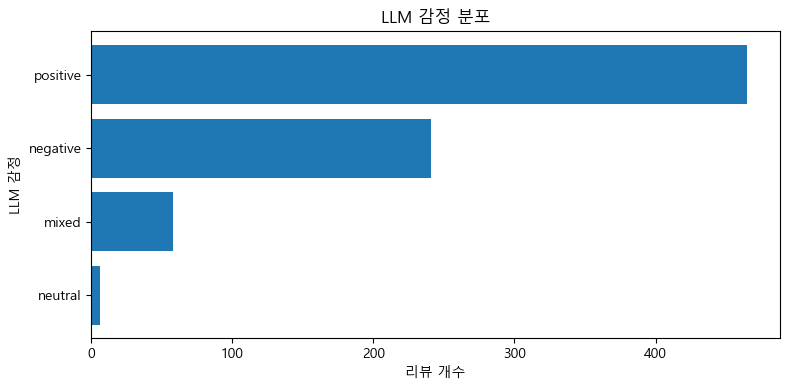

In [10]:
# ============================================================
# 4-1. LLM 감정 분포 그래프
# ============================================================

plot_df = llm_sentiment_summary.sort_values("review_count", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_df["llm_sentiment"], plot_df["review_count"])
plt.title("LLM 감정 분포")
plt.xlabel("리뷰 개수")
plt.ylabel("LLM 감정")
plt.tight_layout()
plt.show()

## 결과 해석

표본 내 Steam 긍정 리뷰는 **511개(66.4%)**, 부정 리뷰는 **259개(33.6%)**로 나타났다.  
LLM 기준으로는 긍정 465개, 부정 241개, 혼합 58개, 중립 6개로 분류되었다.

즉, Action 장르 출시 초기 리뷰에서는 전반적으로 긍정 반응이 더 많았지만, 부정 또는 혼합으로 해석되는 리뷰도 적지 않게 존재한다.  
출시 전 분석에서는 이 부정·혼합 리뷰에 포함된 불편 요소를 확인해 출시 전 체크리스트로 연결하는 것이 중요하다.


# 5. Steam 라벨과 LLM 감정 비교

Steam 추천/비추천 라벨과 LLM 감정 판단은 항상 완전히 같은 의미는 아니다.

예를 들어 Steam에서는 추천 리뷰이지만, 본문에는 조작감이나 반복성에 대한 아쉬움이 함께 들어 있을 수 있다.  
반대로 비추천 리뷰라도 특정 장점은 인정하는 경우가 있다.

이 섹션에서는 Steam 라벨과 LLM 감정의 관계를 확인하여, 단순 추천 여부만으로 놓칠 수 있는 개선 요구를 살펴본다.

In [11]:
# ============================================================
# 5. Steam 라벨과 LLM 감정 비교
# ============================================================

sentiment_relation_summary = (
    df_result["sentiment_relation"]
    .value_counts()
    .rename_axis("sentiment_relation")
    .reset_index(name="review_count")
)
sentiment_relation_summary["ratio_percent"] = (sentiment_relation_summary["review_count"] / len(df_result) * 100).round(1)

display(sentiment_relation_summary)

sentiment_cross = pd.crosstab(
    df_result["steam_label_text"],
    df_result["llm_sentiment"],
    margins=True
)

display(sentiment_cross)

,sentiment_relation,review_count,ratio_percent
0,exact_match,704,91.4
1,partial_match,58,7.5
2,unclear,6,0.8
3,mismatch,2,0.3


llm_sentiment,mixed,negative,neutral,positive,All
steam_label_text,,,,,
negative,19,239,1,0,259
positive,39,2,5,465,511
All,58,241,6,465,770


## 결과 해석

Steam 라벨과 LLM 감정 판단은 대부분 일치하거나 부분적으로 일치했다.  
`exact_match`는 704개, `partial_match`는 58개였고, `unclear`는 6개, `mismatch`는 2개로 나타났다.

`exact_match + partial_match` 기준으로 보면 약 99%가 유효하게 연결되었다.  
이는 LLM 결과가 Steam 추천/비추천 라벨과 크게 어긋나지 않으며, 리뷰 본문을 세부적으로 해석하는 보조 지표로 사용할 수 있음을 의미한다.

다만 `partial_match`는 긍정 리뷰 안의 불만, 부정 리뷰 안의 장점처럼 복합적인 반응을 보여줄 수 있으므로 별도로 해석할 가치가 있다.


# 6. Action 장르 유저가 긍정적으로 평가한 요소

이 섹션에서는 LLM이 긍정 방향으로 분류한 이슈 태그를 집계한다.

`positive_praise`는 “재밌다”, “추천한다”, “잘 만들었다”, “만족스럽다”처럼 전반적 만족 표현에 가까운 태그이다.  
즉, 특정 기능이나 시스템에 대한 세부 평가라기보다는 LLM이 리뷰 본문에서 전체적인 긍정 반응을 감지했을 때 부여한 분류로 해석한다.

따라서 출시 전 전략으로 연결하기 위해서는 `positive_praise`를 전체 만족 신호로 참고하고, 실제 개발 방향은 `게임플레이 루프`, `그래픽/사운드`, `난이도`, `콘텐츠 분량`, `가격/가치`처럼 구체적인 강점 태그를 중심으로 확인한다.


In [12]:
# ============================================================
# 6. Action 장르 유저가 긍정적으로 평가한 요소
# ============================================================

positive_tag_summary = (
    df_tag[df_tag["tag_sentiment"] == "positive"]
    .groupby(["tag_category", "issue_name_kor"], as_index=False)
    .agg(
        positive_tag_count=("recommendationid", "size"),
        affected_reviews=("recommendationid", "nunique"),
        avg_playtime_hours=("playtime_at_review_hours", "mean"),
    )
    .sort_values(["affected_reviews", "positive_tag_count"], ascending=False)
)

positive_tag_summary["avg_playtime_hours"] = positive_tag_summary["avg_playtime_hours"].round(1)

display(positive_tag_summary)

# positive_praise를 제외한 구체적 강점
positive_specific_summary = positive_tag_summary[positive_tag_summary["tag_category"] != "positive_praise"].copy()
display(positive_specific_summary.head(10))

,tag_category,issue_name_kor,positive_tag_count,affected_reviews,avg_playtime_hours
11,positive_praise,긍정 칭찬,463,462,15.1
5,gameplay_loop,게임플레이 루프,65,64,43.4
6,graphics_audio,그래픽/사운드,37,37,7.4
4,difficulty,난이도,26,26,15.4
14,story,스토리,13,13,46.4
1,content_volume,콘텐츠 분량,12,12,12.3
12,price_value,가격/가치,12,12,10.9
3,developer_communication,개발사 소통,9,9,25.8
2,control,조작감,6,6,3.0
9,other,기타,5,5,11.0


,tag_category,issue_name_kor,positive_tag_count,affected_reviews,avg_playtime_hours
5,gameplay_loop,게임플레이 루프,65,64,43.4
6,graphics_audio,그래픽/사운드,37,37,7.4
4,difficulty,난이도,26,26,15.4
14,story,스토리,13,13,46.4
1,content_volume,콘텐츠 분량,12,12,12.3
12,price_value,가격/가치,12,12,10.9
3,developer_communication,개발사 소통,9,9,25.8
2,control,조작감,6,6,3.0
9,other,기타,5,5,11.0
13,progression_grind,성장/반복 노가다,4,4,9.9


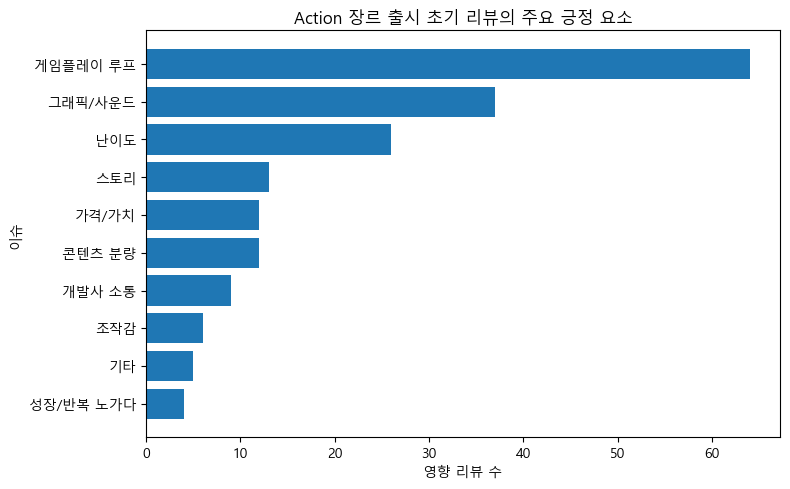

In [13]:
# ============================================================
# 6-1. 구체적 긍정 요소 그래프
# ============================================================

plot_df = positive_specific_summary.head(10).sort_values("affected_reviews", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["issue_name_kor"], plot_df["affected_reviews"])
plt.title("Action 장르 출시 초기 리뷰의 주요 긍정 요소")
plt.xlabel("영향 리뷰 수")
plt.ylabel("이슈")
plt.tight_layout()
plt.show()

## 결과 해석

긍정 태그에서는 전반적인 만족을 나타내는 `positive_praise`가 가장 많이 나타났다.  
이는 Action 장르 유저들이 리뷰에서 “재미있다”, “추천한다”, “기대 이상이다”처럼 전체 경험에 대한 긍정 반응을 많이 남겼다는 의미이다.

다만 `positive_praise`는 구체적인 개발 전략을 직접 제시하는 세부 이슈라기보다는 전체 만족 신호에 가깝다.  
따라서 실제 출시 전 전략을 도출할 때는 `positive_praise` 자체보다, 이를 제외한 구체적 긍정 요소를 함께 확인하는 것이 더 적절하다.

구체적인 요소 중에서는 **게임플레이 루프**가 가장 중요한 긍정 요소로 나타났다.  
이는 Action 장르 유저들이 전투, 이동, 반복 플레이, 성장, 보상 구조처럼 실제 플레이 과정에서 반복적으로 경험하는 요소를 중요하게 평가한다는 의미로 해석할 수 있다.


# 7. Action 장르 유저가 불만을 가진 요소

출시 전 분석에서 가장 중요한 부분은 유사 장르 게임에서 반복적으로 나타난 부정 요인을 파악하는 것이다.

이 섹션에서는 부정 태그를 기준으로 다음 항목을 확인한다.

| 항목 | 의미 |
|---|---|
| 부정 태그 수 | 해당 이슈가 태그로 추출된 횟수 |
| 영향 리뷰 수 | 몇 개 리뷰에서 해당 문제가 나타났는지 |
| High urgency 리뷰 수 | LLM이 빠른 확인이 필요하다고 판단한 리뷰 수 |
| 평균 플레이타임 | 초반 이탈 문제인지, 일정 플레이 후 누적 불만인지 참고 |

In [14]:
# ============================================================
# 7. Action 장르 유저가 불만을 가진 요소
# ============================================================

negative_tag_summary = (
    df_tag[df_tag["tag_sentiment"] == "negative"]
    .groupby(["tag_category", "issue_name_kor"], as_index=False)
    .agg(
        negative_tag_count=("recommendationid", "size"),
        affected_reviews=("recommendationid", "nunique"),
        high_urgency_reviews=("urgency", lambda x: (x == "high").sum()),
        avg_playtime_hours=("playtime_at_review_hours", "mean"),
    )
    .sort_values(["affected_reviews", "negative_tag_count"], ascending=False)
)

negative_tag_summary["avg_playtime_hours"] = negative_tag_summary["avg_playtime_hours"].round(1)

display(negative_tag_summary)

,tag_category,issue_name_kor,negative_tag_count,affected_reviews,high_urgency_reviews,avg_playtime_hours
7,gameplay_loop,게임플레이 루프,156,149,97,10.3
1,bug,버그,92,89,68,17.1
3,control,조작감,68,68,47,12.0
0,balance,밸런스,63,57,48,17.8
6,difficulty,난이도,57,56,38,9.2
18,ui_ux,UI/UX,56,56,31,17.2
2,content_volume,콘텐츠 분량,37,37,17,22.9
8,graphics_audio,그래픽/사운드,37,36,17,10.5
16,story,스토리,33,33,18,19.1
11,other,기타,32,31,16,20.9


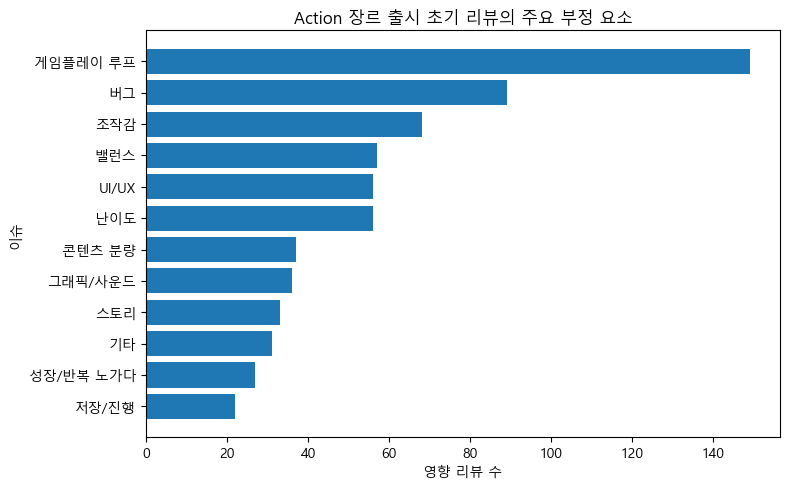

In [15]:
# ============================================================
# 7-1. 주요 부정 요소 그래프
# ============================================================

plot_df = negative_tag_summary.head(12).sort_values("affected_reviews", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["issue_name_kor"], plot_df["affected_reviews"])
plt.title("Action 장르 출시 초기 리뷰의 주요 부정 요소")
plt.xlabel("영향 리뷰 수")
plt.ylabel("이슈")
plt.tight_layout()
plt.show()

## 결과 해석

부정 태그에서는 **게임플레이 루프, 버그, 조작감, UI/UX, 밸런스, 난이도**가 상위에 나타났다.

이 결과는 Action 장르의 출시 초기 부정 반응이 단순한 취향 차이보다는, 실제 플레이 경험을 방해하는 요소에서 많이 발생한다는 것을 보여준다.  
특히 게임플레이 루프, 조작감, UI/UX, 밸런스, 난이도는 게임의 핵심 재미와 직접 연결되므로 출시 전 테스트에서 우선 확인해야 한다.

또한 버그, 크래시, 저장/진행, 성능 문제는 High urgency 비중이 높게 나타날 수 있으므로, 출시 직전 QA 단계에서 별도 체크리스트로 관리할 필요가 있다.


# 8. 긍정과 부정이 함께 나타난 핵심 평가 축

일부 이슈는 긍정과 부정 양쪽에서 모두 많이 등장한다.  
이런 이슈는 단순한 장점이나 단점이 아니라, Action 장르 유저 평가를 좌우하는 핵심 축으로 보는 것이 적절하다.

예를 들어 게임플레이 루프는 잘 설계되면 강점이 되지만, 반복성이 약하거나 전투·이동 구조가 불편하면 곧바로 부정 평가로 이어질 수 있다.

In [16]:
# ============================================================
# 8. 긍정과 부정이 함께 나타난 핵심 평가 축
# ============================================================

issue_sentiment_pivot = pd.crosstab(
    df_tag["issue_name_kor"],
    df_tag["tag_sentiment"]
)

for col in ["positive", "negative", "mixed", "neutral"]:
    if col not in issue_sentiment_pivot.columns:
        issue_sentiment_pivot[col] = 0

issue_sentiment_pivot["total"] = issue_sentiment_pivot[["positive", "negative", "mixed", "neutral"]].sum(axis=1)
issue_sentiment_pivot = issue_sentiment_pivot.sort_values("total", ascending=False)

display(issue_sentiment_pivot)

# 긍정과 부정이 모두 존재하는 이슈만 확인
both_side_issues = issue_sentiment_pivot[
    (issue_sentiment_pivot["positive"] > 0) &
    (issue_sentiment_pivot["negative"] > 0)
].copy()

display(both_side_issues)

tag_sentiment,mixed,negative,neutral,positive,total
issue_name_kor,,,,,
긍정 칭찬,0,0,0,463,463
게임플레이 루프,8,156,18,65,247
난이도,1,57,14,26,98
버그,0,92,3,0,95
그래픽/사운드,2,37,6,37,82
조작감,1,68,1,6,76
콘텐츠 분량,1,37,20,12,70
밸런스,1,63,2,1,67
UI/UX,0,56,4,4,64


tag_sentiment,mixed,negative,neutral,positive,total
issue_name_kor,,,,,
게임플레이 루프,8,156,18,65,247
난이도,1,57,14,26,98
그래픽/사운드,2,37,6,37,82
조작감,1,68,1,6,76
콘텐츠 분량,1,37,20,12,70
밸런스,1,63,2,1,67
UI/UX,0,56,4,4,64
기타,1,32,13,5,51
스토리,0,33,4,13,50


## 결과 해석

긍정과 부정이 함께 나타난 대표 이슈는 **게임플레이 루프, 난이도, UI/UX, 조작감, 그래픽/사운드, 콘텐츠 분량, 밸런스**였다.

이런 이슈는 단순히 좋은 요소 또는 나쁜 요소라기보다, Action 장르 유저 평가를 좌우하는 핵심 평가 축으로 해석하는 것이 적절하다.  
예를 들어 게임플레이 루프는 잘 설계되면 강점이 되지만, 반복성이 약하거나 전투·이동 구조가 불편하면 곧바로 부정 평가로 이어질 수 있다.

따라서 출시 전에는 “재미있는 콘셉트인가?”만 확인하는 것이 아니라, 실제 플레이 과정에서 다음 요소가 제대로 작동하는지 점검해야 한다.

- 전투와 이동이 반복해도 피로하지 않은가
- 조작 반응과 카메라가 불편하지 않은가
- 난이도 상승이 납득 가능한가
- UI가 초반 목표와 조작 방법을 충분히 안내하는가
- 콘텐츠 분량과 반복 플레이 동기가 가격대와 기대치에 맞는가


# 9. 시급도 기준으로 본 출시 전 리스크

`urgency`는 LLM이 리뷰 본문을 읽고 개선 시급도를 판단한 값이다.  
출시 전 분석에서는 이를 실제 장애 지표로 보기보다는, 유저가 어떤 문제를 심각하게 받아들였는지 확인하는 보조 기준으로 사용한다.

In [17]:
# ============================================================
# 9. 시급도 기준으로 본 출시 전 리스크
# ============================================================

urgency_summary = (
    df_result["urgency"]
    .value_counts()
    .rename_axis("urgency")
    .reset_index(name="review_count")
)
urgency_summary["ratio_percent"] = (urgency_summary["review_count"] / len(df_result) * 100).round(1)

display(urgency_summary)

high_urgency_issue_summary = (
    df_tag[(df_tag["tag_sentiment"] == "negative") & (df_tag["urgency"] == "high")]
    .groupby(["tag_category", "issue_name_kor"], as_index=False)
    .agg(
        high_urgency_tag_count=("recommendationid", "size"),
        affected_reviews=("recommendationid", "nunique"),
        avg_playtime_hours=("playtime_at_review_hours", "mean"),
    )
    .sort_values(["affected_reviews", "high_urgency_tag_count"], ascending=False)
)
high_urgency_issue_summary["avg_playtime_hours"] = high_urgency_issue_summary["avg_playtime_hours"].round(1)

display(high_urgency_issue_summary)

,urgency,review_count,ratio_percent
0,low,402,52.2
1,high,214,27.8
2,medium,154,20.0


,tag_category,issue_name_kor,high_urgency_tag_count,affected_reviews,avg_playtime_hours
7,gameplay_loop,게임플레이 루프,97,91,10.7
1,bug,버그,68,65,18.1
3,control,조작감,47,47,6.7
0,balance,밸런스,48,42,12.4
6,difficulty,난이도,38,38,6.2
18,ui_ux,UI/UX,31,31,5.8
15,save_progression,저장/진행,21,20,10.6
4,crash,크래시,20,20,13.3
12,performance,성능,18,18,8.9
16,story,스토리,18,18,19.4


## 결과 해석

전체 리뷰 중 High urgency는 **214개**로 나타났다.  
High urgency 부정 이슈에서는 **게임플레이 루프, 버그, 조작감, 밸런스, UI/UX, 난이도**가 주로 확인되었다.

`urgency`는 실제 장애 지표가 아니라, LLM이 리뷰 내용을 읽고 해당 문제가 얼마나 시급하게 개선되어야 하는지 판단한 보조 기준이다.  
따라서 출시 전 분석에서는 이를 “유저가 심각하게 받아들인 문제 후보”를 확인하는 기준으로 활용한다.

이 결과는 Action 장르 출시 전 QA에서 단순히 버그만 보는 것이 아니라, 핵심 플레이 경험 자체가 유저에게 불편하게 받아들여지는지도 함께 확인해야 함을 의미한다.


# 10. 게임별 샘플 수 확인

이번 분석은 특정 게임 하나가 아니라 Action 장르 유사 게임 묶음을 보는 출시 전 분석이다.  
따라서 게임별 리뷰 수가 지나치게 한쪽에 몰려 있는지 확인할 필요가 있다.

단, 일부 게임은 D0-D30 조건에서 리뷰 수가 적기 때문에 게임별 세부 비교보다는 장르 전체의 반복 이슈를 중심으로 해석하는 것이 안전하다.

In [18]:
# ============================================================
# 10. 게임별 샘플 수 확인
# ============================================================

game_sample_summary = (
    df_result
    .groupby(["appid", "game_name"], as_index=False)
    .agg(
        sample_reviews=("recommendationid", "count"),
        positive_reviews=("steam_label_text", lambda x: (x == "positive").sum()),
        negative_reviews=("steam_label_text", lambda x: (x == "negative").sum()),
        high_urgency_reviews=("urgency", lambda x: (x == "high").sum()),
        avg_sentiment_score=("sentiment_score", "mean"),
    )
    .sort_values("sample_reviews", ascending=False)
)

game_sample_summary["avg_sentiment_score"] = game_sample_summary["avg_sentiment_score"].round(2)

display(game_sample_summary)

display(game_sample_summary["sample_reviews"].describe())

,appid,game_name,sample_reviews,positive_reviews,negative_reviews,high_urgency_reviews,avg_sentiment_score
4,1466060,Tainted Grail: The Fall of Avalon,100,50,50,44,3.10
24,3027930,Karate Survivor,100,75,25,24,3.93
16,2514460,GUARDS!,98,61,37,39,3.20
6,1585180,Drova - Forsaken Kin,96,49,47,22,3.24
11,2101890,Zoonomaly,87,54,33,29,3.14
14,2488510,FatalZone,56,18,38,22,2.50
3,1409200,HYPERVIOLENT,41,30,11,12,3.59
0,1054510,Survivalist: Invisible Strain,38,29,9,11,3.76
17,2617090,Fowl Damage,36,36,0,0,4.97
23,3001200,Tails Noir: Rebel Rush,34,34,0,1,4.85


count     28.000000
mean      27.500000
std       35.806579
min        1.000000
25%        2.750000
50%        7.000000
75%       38.750000
max      100.000000
Name: sample_reviews, dtype: float64

# 11. 확장 분석 개요

기존 분석은 LLM이 분류한 감정, 이슈 태그, 개선 시급도를 집계해 Action 장르의 공통적인 유저 반응을 확인하였다.

이번 확장 분석에서는 여기에 게임 메타데이터를 결합하여 다음 세 가지 관점으로 다시 비교한다.

| 분석 | 기준 컬럼 | 목적 |
|---|---|---|
| 가격대별 이슈 비교 | `price_group` | 가격대에 따라 유저 불만과 시급도 차이가 있는지 확인 |
| Steam 태그별 이슈 비교 | `steam_tag` | 세부 태그별로 반복되는 부정 이슈가 다른지 확인 |
| 플레이 방식별 이슈 비교 | `play_mode_group` | 싱글/멀티/협동 여부에 따라 출시 전 점검 요소가 달라지는지 확인 |

초기 반응 등급별 분석은 이번 보고서에서 제외한다. 표본 기준 긍정률로 등급을 나누면 실제 시장 반응과 혼동될 수 있기 때문이다.


# 12. 가격대별 이슈 비교

## 이 분석을 하는 이유

가격대별 이슈 비교는 **출시 전 가격 전략**과 연결하기 위한 분석이다.  
같은 Action 장르 게임이라도 가격대가 달라지면 유저가 기대하는 콘텐츠 분량, 완성도, 기술 안정성 수준이 달라질 수 있다.

따라서 이 섹션에서는 가격대별로 어떤 **긍정 요소**와 **부정 이슈**가 반복적으로 나타나는지 확인한다.  
단순 이슈 태그 수만 보면 리뷰 수가 많은 가격대가 크게 보일 수 있으므로, 가격대별 리뷰 수 대비 이슈 태그 비율을 함께 사용하였다.

## 한줄 결과 설명

가격대별 주요 긍정 요소와 부정 이슈를 비교하여, 출시 가격을 정할 때 해당 가격대에서 유저가 기대하는 강점과 리스크를 함께 확인한다.


이슈명 컬럼: issue_name_kor
[가격대별 분석 표본]


,가격대,리뷰수,게임수
0,0-5,161,8
1,5-10,282,6
2,10-20,116,10
3,20-40,111,3
4,40+,100,1


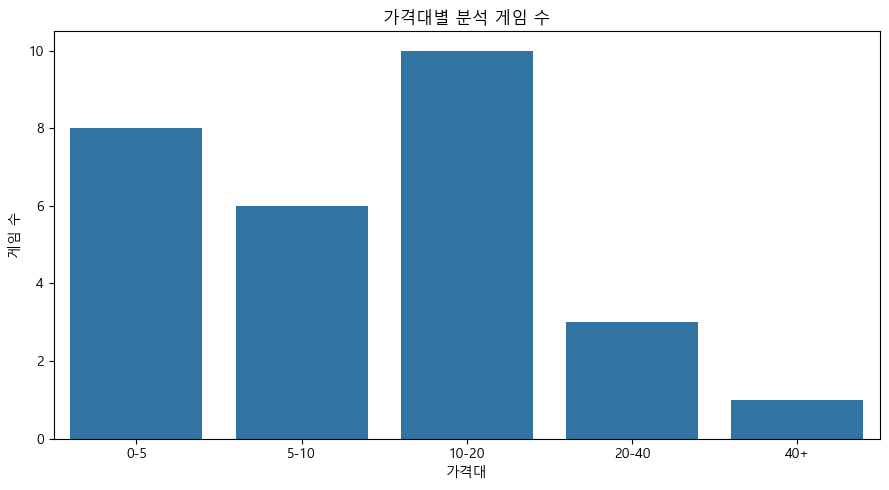

In [19]:
# ============================================================
# 12-0. 가격대별 이슈 비교 공통 설정
# ============================================================
# 이 섹션에서 공통으로 사용할 기준값을 먼저 정리한다.
# price_review_count는 이슈 비율을 계산할 때 분모로 사용한다.

price_group_order = ["0-5", "5-10", "10-20", "20-40", "40+"]
issue_col = "issue_name_kor" if "issue_name_kor" in df_tag.columns else "tag_category"

price_review_count = (
    df_result
    .groupby("price_group")["recommendationid"]
    .nunique()
    .reindex(price_group_order)
)

price_game_count = (
    df_result
    .drop_duplicates(["appid", "price_group"])
    .groupby("price_group")["appid"]
    .nunique()
    .reindex(price_group_order)
)

price_base_summary = pd.DataFrame({
    "리뷰수": price_review_count,
    "게임수": price_game_count,
}).reset_index().rename(columns={"price_group": "가격대"})

print("이슈명 컬럼:", issue_col)
print("[가격대별 분석 표본]")
display(price_base_summary)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=price_base_summary,
    x="가격대",
    y="게임수",
)
plt.title("가격대별 분석 게임 수")
plt.xlabel("가격대")
plt.ylabel("게임 수")
plt.tight_layout()
plt.show()


## 가격대별 표본 확인

이 표와 그래프는 가격대별로 몇 개의 게임과 리뷰가 포함되었는지 확인하기 위한 것이다.  
가격대별 이슈 비율을 해석할 때, 특정 가격대의 게임 수가 너무 적으면 결과를 조심해서 해석해야 한다.

**한줄 결과 설명:** 가격대별 게임 수를 먼저 확인하여, 이후 이슈 비교 결과가 충분한 표본을 바탕으로 나온 것인지 점검하였다.


[가격대별 주요 긍정 요소 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
price_group,,,,,,,,,,
0-5,0.0,3.7,0.0,17.4,8.7,0.0,2.5,1.2,2.5,1.9
5-10,0.4,0.7,1.4,5.3,4.3,0.4,3.5,0.0,0.4,1.8
10-20,1.7,2.6,2.6,13.8,3.4,2.6,5.2,3.4,0.9,1.7
20-40,0.0,0.9,1.8,4.5,3.6,0.9,4.5,5.4,0.0,1.8
40+,1.0,0.0,0.0,1.0,3.0,0.0,1.0,1.0,0.0,0.0


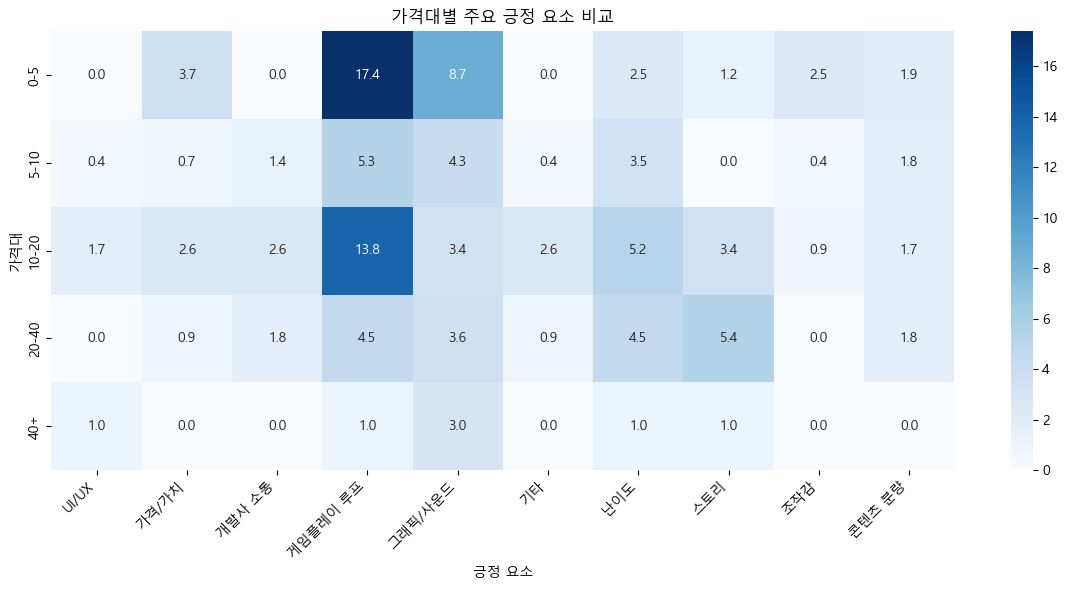

In [20]:
# ============================================================
# 12-1. 가격대별 주요 긍정 요소 히트맵
# ============================================================
# 가격대별로 어떤 긍정 요소가 자주 나타나는지 확인한다.
# 값은 가격대별 리뷰 수 대비 긍정 이슈 태그 비율이다.
# 단, '긍정 칭찬'은 전반적인 만족 표현에 가까우므로 제외한다.

positive_exclude_keywords = ["긍정 칭찬", "positive praise", "praise"]

price_positive = df_tag[
    (df_tag["tag_sentiment"] == "positive") &
    (df_tag["price_group"].notna()) &
    (df_tag[issue_col].notna())
].copy()

# 전반적인 칭찬 태그 제외
price_positive = price_positive[
    ~price_positive[issue_col].astype(str).str.lower().isin(
        [word.lower() for word in positive_exclude_keywords]
    )
]

# 전체 가격대에서 많이 나온 긍정 요소 상위 10개 선정
top_positive_issues = (
    price_positive[issue_col]
    .value_counts()
    .head(10)
    .index
)

price_positive_count = (
    price_positive[price_positive[issue_col].isin(top_positive_issues)]
    .groupby(["price_group", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

price_positive_pivot_count = (
    price_positive_count
    .pivot_table(
        index="price_group",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0,
    )
    .reindex(price_group_order)
    .fillna(0)
)

# 가격대별 리뷰 수 대비 비율 계산
price_positive_pivot_rate = price_positive_pivot_count.div(price_review_count, axis=0) * 100

print("[가격대별 주요 긍정 요소 비율(%)]")
display(price_positive_pivot_rate.round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(
    price_positive_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
)

plt.title("가격대별 주요 긍정 요소 비교")
plt.xlabel("긍정 요소")
plt.ylabel("가격대")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [21]:
# ============================================================
# 12-2. 가격대별 긍정 요소 결과 요약
# ============================================================
# 각 가격대에서 가장 비율이 높은 긍정 요소를 뽑아 요약한다.

positive_result_rows = []

for price_group in price_group_order:
    if price_group not in price_positive_pivot_rate.index:
        continue

    row = price_positive_pivot_rate.loc[price_group].dropna()

    if len(row) == 0 or row.sum() == 0:
        top_issue = "확인 어려움"
        top_rate = 0
    else:
        top_issue = row.idxmax()
        top_rate = row.max()

    positive_result_rows.append({
        "가격대": price_group,
        "주요 긍정 요소": top_issue,
        "리뷰 수 대비 비율(%)": round(top_rate, 1),
    })

price_positive_result_summary = pd.DataFrame(positive_result_rows)

print("[가격대별 긍정 요소 요약]")
display(price_positive_result_summary)


[가격대별 긍정 요소 요약]


,가격대,주요 긍정 요소,리뷰 수 대비 비율(%)
0,0-5,게임플레이 루프,17.4
1,5-10,게임플레이 루프,5.3
2,10-20,게임플레이 루프,13.8
3,20-40,스토리,5.4
4,40+,그래픽/사운드,3.0


## 가격대별 긍정 요소 결과 설명

이 히트맵은 가격대별로 어떤 긍정 요소가 상대적으로 자주 나타나는지 보여준다.  
값은 단순 태그 수가 아니라, 해당 가격대의 리뷰 수 대비 긍정 이슈 태그 비율로 계산하였다.

`긍정 칭찬`은 전반적인 만족, 재미, 추천 의사에 가까운 태그이므로 제외하였다.  
따라서 이 결과는 가격대별로 실제 강점으로 해석할 수 있는 요소를 확인하는 데 사용한다.

**한줄 결과 설명:** 가격대별 긍정 요소를 보면, 해당 가격대에서 유저가 어떤 강점에 만족하는지 파악할 수 있다.


[가격대별 주요 부정 이슈 비율(%)]


issue_name_kor,UI/UX,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,스토리,조작감,콘텐츠 분량
price_group,,,,,,,,,,
0-5,3.7,8.7,1.2,2.5,2.5,8.1,4.3,0.0,9.3,2.5
5-10,6.0,26.6,3.2,3.5,11.7,10.3,12.1,2.1,7.1,5.3
10-20,16.4,20.7,8.6,3.4,6.0,7.8,12.1,0.9,12.1,3.4
20-40,8.1,20.7,5.4,1.8,9.9,8.1,7.2,16.2,9.9,2.7
40+,5.0,20.0,10.0,12.0,2.0,3.0,29.0,8.0,8.0,11.0


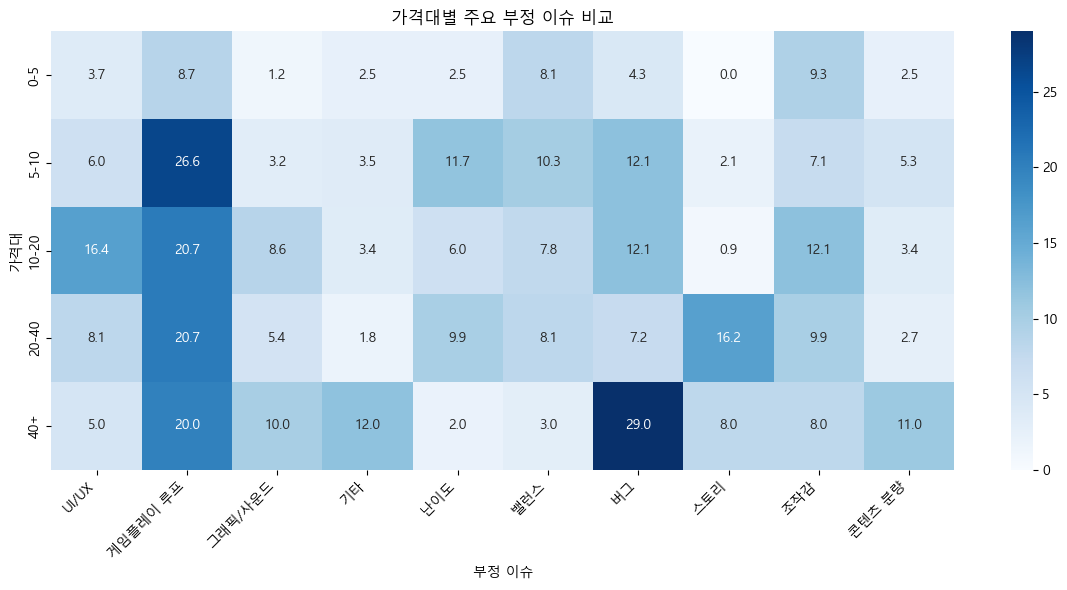

In [22]:
# ============================================================
# 12-3. 가격대별 주요 부정 이슈 히트맵
# ============================================================
# 가격대별로 어떤 부정 이슈가 자주 나타나는지 확인한다.
# 값은 가격대별 리뷰 수 대비 부정 이슈 태그 비율이다.

price_negative = df_tag[
    (df_tag["tag_sentiment"] == "negative") &
    (df_tag["price_group"].notna()) &
    (df_tag[issue_col].notna())
].copy()

# 전체 가격대에서 많이 나온 부정 이슈 상위 10개 선정
top_negative_issues = (
    price_negative[issue_col]
    .value_counts()
    .head(10)
    .index
)

price_negative_count = (
    price_negative[price_negative[issue_col].isin(top_negative_issues)]
    .groupby(["price_group", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

price_negative_pivot_count = (
    price_negative_count
    .pivot_table(
        index="price_group",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0,
    )
    .reindex(price_group_order)
    .fillna(0)
)

# 가격대별 리뷰 수 대비 비율 계산
price_negative_pivot_rate = price_negative_pivot_count.div(price_review_count, axis=0) * 100

print("[가격대별 주요 부정 이슈 비율(%)]")
display(price_negative_pivot_rate.round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(
    price_negative_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
)

plt.title("가격대별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("가격대")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [23]:
# ============================================================
# 12-4. 가격대별 부정 이슈 결과 요약
# ============================================================
# 각 가격대에서 가장 비율이 높은 부정 이슈를 뽑아 요약한다.

negative_result_rows = []

for price_group in price_group_order:
    if price_group not in price_negative_pivot_rate.index:
        continue

    row = price_negative_pivot_rate.loc[price_group].dropna()

    if len(row) == 0 or row.sum() == 0:
        top_issue = "확인 어려움"
        top_rate = 0
    else:
        top_issue = row.idxmax()
        top_rate = row.max()

    negative_result_rows.append({
        "가격대": price_group,
        "주요 부정 이슈": top_issue,
        "리뷰 수 대비 비율(%)": round(top_rate, 1),
    })

price_negative_result_summary = pd.DataFrame(negative_result_rows)

print("[가격대별 부정 이슈 요약]")
display(price_negative_result_summary)


[가격대별 부정 이슈 요약]


,가격대,주요 부정 이슈,리뷰 수 대비 비율(%)
0,0-5,조작감,9.3
1,5-10,게임플레이 루프,26.6
2,10-20,게임플레이 루프,20.7
3,20-40,게임플레이 루프,20.7
4,40+,버그,29.0


## 가격대별 부정 이슈 결과 설명

이 히트맵은 가격대별로 어떤 부정 이슈가 상대적으로 자주 나타나는지 보여준다.  
값은 단순 태그 수가 아니라, 해당 가격대의 리뷰 수 대비 부정 이슈 태그 비율로 계산하였다.

이를 통해 출시 가격을 정할 때 단순히 유사 게임의 가격만 비교하지 않고,  
해당 가격대에서 반복되는 불만 요인도 함께 고려할 수 있다.

**한줄 결과 설명:** 가격대별 부정 이슈는 해당 가격대에서 출시 전 반드시 점검해야 할 리스크 후보를 보여준다.


In [24]:
# ============================================================
# 12-5. 가격대별 이슈 비교 최종 요약
# ============================================================
# 긍정 요소 요약과 부정 이슈 요약을 하나의 표로 합친다.

price_issue_final_summary = price_positive_result_summary.merge(
    price_negative_result_summary,
    on="가격대",
    how="outer",
)

print("[가격대별 이슈 비교 최종 요약]")
display(price_issue_final_summary)


[가격대별 이슈 비교 최종 요약]


,가격대,주요 긍정 요소,리뷰 수 대비 비율(%)_x,주요 부정 이슈,리뷰 수 대비 비율(%)_y
0,0-5,게임플레이 루프,17.4,조작감,9.3
1,10-20,게임플레이 루프,13.8,게임플레이 루프,20.7
2,20-40,스토리,5.4,게임플레이 루프,20.7
3,40+,그래픽/사운드,3.0,버그,29.0
4,5-10,게임플레이 루프,5.3,게임플레이 루프,26.6


## 가격대별 이슈 비교 결과 요약

가격대별 분석에서는 가격대마다 유저가 만족한 요소와 불만을 느낀 요소를 함께 확인하였다.  
긍정 요소는 해당 가격대에서 유저가 강점으로 받아들인 부분을 보여주고, 부정 이슈는 출시 전 점검해야 할 리스크를 보여준다.

이 결과를 활용하면 출시 전 가격을 정할 때 단순히 유사 게임의 가격만 참고하는 것이 아니라,  
해당 가격대에서 유저가 기대하는 콘텐츠 분량, 완성도, 조작감, UI/UX, 기술 안정성 등을 함께 고려할 수 있다.

**최종 요약:** 가격대별 이슈 비교는 출시 가격을 정할 때 “어떤 강점을 강조해야 하는지”와 “어떤 불만을 미리 줄여야 하는지”를 함께 보여주는 분석이다.


# 13. Steam 태그별 이슈 비교

## 이 분석을 하는 이유

Steam 태그별 이슈 비교는 같은 Action 장르 안에서도 **세부 게임 유형에 따라 유저가 중요하게 보는 요소가 달라지는지** 확인하는 분석이다.

예를 들어 Roguelike 계열은 반복 플레이와 성장 구조가 중요할 수 있고, Survival 계열은 자원 관리와 콘텐츠 밀도가 중요할 수 있다.  
따라서 Steam 태그별로 주요 긍정 요소와 부정 이슈를 비교하면, 태그 조합에 따른 출시 전 개발 우선순위를 더 구체화할 수 있다.

긍정 요소 분석에서는 전반적인 만족 표현에 가까운 `긍정 칭찬`을 제외하고, 실제 강점으로 해석할 수 있는 요소만 비교하였다.

## 한줄 결과 설명

같은 Action 장르 안에서도 Steam 태그에 따라 유저가 기대하는 강점과 불만 요인이 달라질 수 있으므로, 태그 조합에 맞춘 출시 전 전략이 필요하다.


이슈명 컬럼: issue_name_kor
[Steam 태그별 분석 표본]


,Steam 태그,리뷰 수,게임 수
0,Action,366,17
1,Exploration,336,7
2,First-Person,329,7
3,RPG,301,9
4,Open World,286,4
5,2D,267,9
6,Action RPG,262,6
7,Character Customization,254,5
8,Singleplayer,209,4
9,3D,186,7


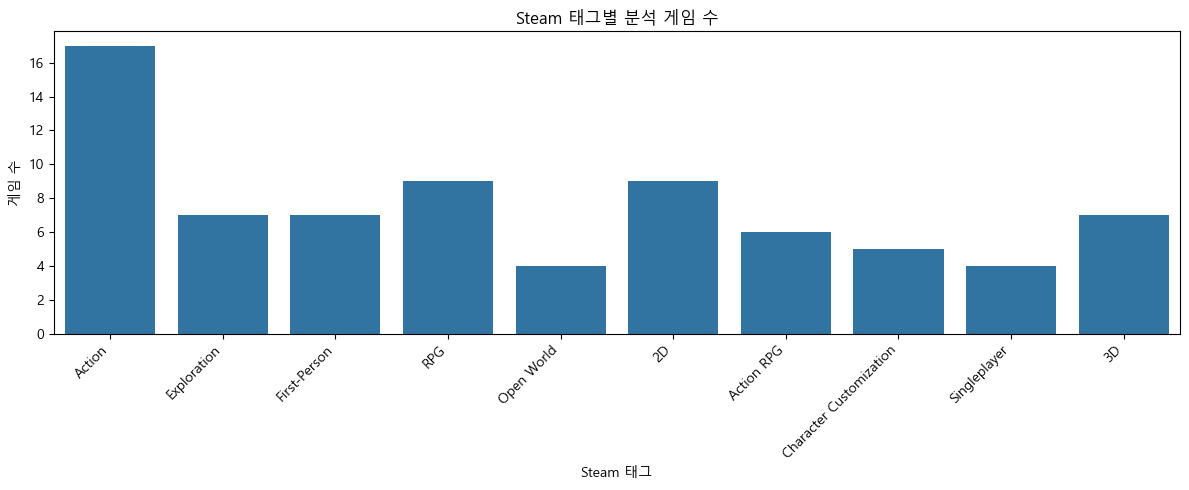

In [ ]:
# ============================================================
# 13-0. Steam 태그별 이슈 비교 공통 설정
# ============================================================
# Steam 태그는 하나의 리뷰가 여러 태그에 동시에 속할 수 있다.
# 그래서 태그별 리뷰 수를 먼저 확인하고, 리뷰 수가 많은 상위 태그를 분석 대상으로 사용한다.

issue_col = "issue_name_kor" if "issue_name_kor" in df_tag_for_steam_tag.columns else "tag_category"
positive_exclude_keywords = ["긍정 칭찬", "positive praise", "praise"]

steam_tag_review_count = (
    df_tag_for_steam_tag[["steam_tag", "recommendationid"]]
    .drop_duplicates()
    .groupby("steam_tag")
    .size()
    .sort_values(ascending=False)
)

# 리뷰 수 기준 상위 10개 Steam 태그 사용
top_steam_tags = steam_tag_review_count.head(10).index.tolist()
steam_tag_review_count_top = steam_tag_review_count.loc[top_steam_tags]

steam_tag_game_count = (
    df_tag_for_steam_tag[["steam_tag", "appid"]]
    .drop_duplicates()
    .groupby("steam_tag")["appid"]
    .nunique()
    .reindex(top_steam_tags)
)

steam_tag_base_summary = pd.DataFrame({
    "리뷰수": steam_tag_review_count_top,
    "게임수": steam_tag_game_count,
}).reset_index().rename(columns={"steam_tag": "Steam 태그"})

print("이슈명 컬럼:", issue_col)
print("[Steam 태그별 분석 표본]")
display(steam_tag_base_summary)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=steam_tag_base_summary,
    x="Steam 태그",
    y="게임수",
)
plt.title("Steam 태그별 분석 게임 수")
plt.xlabel("Steam 태그")
plt.ylabel("게임 수")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Steam 태그별 표본 확인

이 표와 그래프는 Steam 태그별로 몇 개의 게임과 리뷰가 포함되었는지 확인하기 위한 것이다.  
Steam 태그는 하나의 게임이 여러 태그를 동시에 가질 수 있으므로, 태그별 게임 수는 중복 포함될 수 있다.

**한줄 결과 설명:** Steam 태그별 게임 수를 먼저 확인하여, 특정 태그의 이슈가 충분한 표본을 바탕으로 나온 결과인지 점검하였다.


[Steam 태그별 주요 긍정 요소 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
steam_tag,,,,,,,,,,
Action,0.3,1.6,1.4,7.9,3.8,1.1,4.4,0.8,0.5,1.9
Exploration,0.3,0.6,0.6,5.7,5.1,0.3,2.7,2.4,0.3,0.9
First-Person,0.9,0.6,1.5,3.0,4.0,0.0,2.1,0.9,0.0,0.3
RPG,1.0,1.7,1.7,7.3,3.0,0.7,3.3,3.7,0.0,1.0
Open World,0.3,0.7,0.7,2.4,4.9,0.3,2.1,2.4,0.0,1.0
2D,0.4,3.0,0.7,11.6,7.1,1.5,4.9,2.6,1.1,2.2
Action RPG,0.4,0.8,1.1,3.1,2.7,0.4,1.9,2.7,0.0,1.1
Character Customization,0.4,0.4,1.2,5.1,3.5,0.4,3.5,3.5,0.8,2.0
Singleplayer,0.5,1.9,0.0,6.7,6.2,0.0,1.0,0.5,1.4,1.4


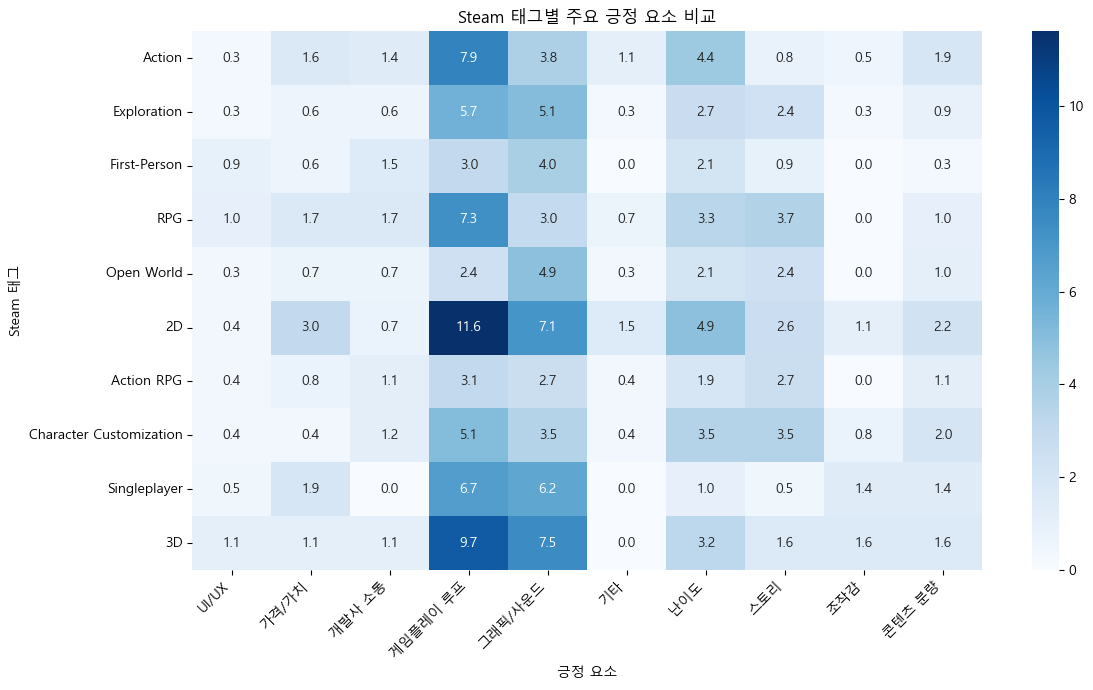

In [26]:
# ============================================================
# 13-1. Steam 태그별 주요 긍정 요소 히트맵
# ============================================================
# 긍정 요소는 '긍정 칭찬'을 제외하고 본다.
# 값은 Steam 태그별 리뷰 수 대비 긍정 이슈 태그 비율이다.

steam_positive = df_tag_for_steam_tag[
    (df_tag_for_steam_tag["tag_sentiment"] == "positive") &
    (df_tag_for_steam_tag["steam_tag"].isin(top_steam_tags)) &
    (df_tag_for_steam_tag[issue_col].notna())
].copy()

# 전반적인 칭찬 태그 제외
steam_positive = steam_positive[
    ~steam_positive[issue_col].astype(str).str.lower().isin(
        [word.lower() for word in positive_exclude_keywords]
    )
]

top_positive_issues = (
    steam_positive[issue_col]
    .value_counts()
    .head(10)
    .index
)

steam_positive_count = (
    steam_positive[steam_positive[issue_col].isin(top_positive_issues)]
    .groupby(["steam_tag", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

steam_positive_pivot_count = (
    steam_positive_count
    .pivot_table(
        index="steam_tag",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0,
    )
    .reindex(top_steam_tags)
    .fillna(0)
)

steam_positive_pivot_rate = steam_positive_pivot_count.div(steam_tag_review_count_top, axis=0) * 100

print("[Steam 태그별 주요 긍정 요소 비율(%)]")
display(steam_positive_pivot_rate.round(1))

plt.figure(figsize=(12, 7))
sns.heatmap(
    steam_positive_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
)
plt.title("Steam 태그별 주요 긍정 요소 비교")
plt.xlabel("긍정 요소")
plt.ylabel("Steam 태그")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [27]:
# ============================================================
# 13-2. Steam 태그별 긍정 요소 결과 요약
# ============================================================
# 각 Steam 태그에서 가장 비율이 높은 긍정 요소를 뽑아 요약한다.

steam_positive_rows = []

for steam_tag in top_steam_tags:
    if steam_tag not in steam_positive_pivot_rate.index:
        continue

    row = steam_positive_pivot_rate.loc[steam_tag].dropna()

    if len(row) == 0 or row.sum() == 0:
        top_issue = "확인 어려움"
        top_rate = 0
    else:
        top_issue = row.idxmax()
        top_rate = row.max()

    steam_positive_rows.append({
        "Steam 태그": steam_tag,
        "주요 긍정 요소": top_issue,
        "리뷰 수 대비 비율(%)": round(top_rate, 1),
    })

steam_positive_result_summary = pd.DataFrame(steam_positive_rows)

print("[Steam 태그별 긍정 요소 요약]")
display(steam_positive_result_summary)


[Steam 태그별 긍정 요소 요약]


,Steam 태그,주요 긍정 요소,리뷰 수 대비 비율(%)
0,Action,게임플레이 루프,7.9
1,Exploration,게임플레이 루프,5.7
2,First-Person,그래픽/사운드,4.0
3,RPG,게임플레이 루프,7.3
4,Open World,그래픽/사운드,4.9
5,2D,게임플레이 루프,11.6
6,Action RPG,게임플레이 루프,3.1
7,Character Customization,게임플레이 루프,5.1
8,Singleplayer,게임플레이 루프,6.7
9,3D,게임플레이 루프,9.7


## Steam 태그별 긍정 요소 결과 설명

이 히트맵은 Steam 태그별로 어떤 긍정 요소가 상대적으로 자주 나타나는지 보여준다.  
값은 태그별 리뷰 수 대비 긍정 이슈 태그 비율로 계산하였다.

`긍정 칭찬`은 단순한 전반적 만족 표현에 가까우므로 제외하였다.  
따라서 이 결과는 태그별로 실제 강점으로 볼 수 있는 요소를 확인하는 데 사용한다.

**한줄 결과 설명:** Steam 태그별 긍정 요소를 보면, 세부 게임 유형별로 어떤 강점을 강화해야 하는지 파악할 수 있다.


[Steam 태그별 주요 부정 이슈 비율(%)]


issue_name_kor,UI/UX,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,스토리,조작감,콘텐츠 분량
steam_tag,,,,,,,,,,
Action,7.9,24.3,3.8,3.6,10.9,9.3,10.4,1.6,8.5,5.2
Exploration,6.2,22.0,6.5,5.7,8.0,4.8,16.1,9.5,9.5,4.5
First-Person,8.2,26.4,6.7,5.5,10.9,8.2,20.1,4.6,7.6,6.1
RPG,10.3,20.9,8.0,6.0,5.6,6.0,14.6,9.0,10.0,5.6
Open World,7.0,25.9,8.0,7.0,9.1,5.6,17.1,11.2,9.1,5.2
2D,6.0,15.0,4.1,2.2,6.0,7.9,4.1,6.7,9.0,2.6
Action RPG,5.7,22.9,6.5,7.3,5.0,8.0,14.9,9.9,7.6,8.0
Character Customization,9.1,20.1,7.1,6.7,6.3,4.7,15.4,10.2,11.0,6.3
Singleplayer,4.8,15.8,5.7,7.7,2.4,8.6,17.2,3.8,9.1,7.2


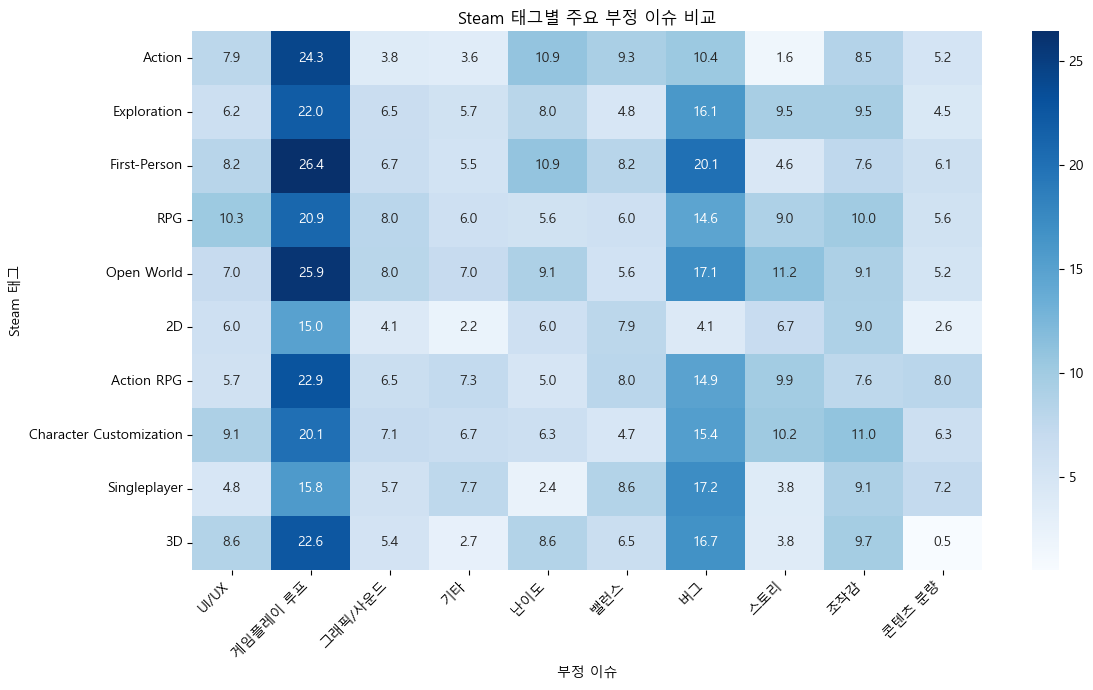

In [28]:
# ============================================================
# 13-3. Steam 태그별 주요 부정 이슈 히트맵
# ============================================================
# 값은 Steam 태그별 리뷰 수 대비 부정 이슈 태그 비율이다.

steam_negative = df_tag_for_steam_tag[
    (df_tag_for_steam_tag["tag_sentiment"] == "negative") &
    (df_tag_for_steam_tag["steam_tag"].isin(top_steam_tags)) &
    (df_tag_for_steam_tag[issue_col].notna())
].copy()

top_negative_issues = (
    steam_negative[issue_col]
    .value_counts()
    .head(10)
    .index
)

steam_negative_count = (
    steam_negative[steam_negative[issue_col].isin(top_negative_issues)]
    .groupby(["steam_tag", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

steam_negative_pivot_count = (
    steam_negative_count
    .pivot_table(
        index="steam_tag",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0,
    )
    .reindex(top_steam_tags)
    .fillna(0)
)

steam_negative_pivot_rate = steam_negative_pivot_count.div(steam_tag_review_count_top, axis=0) * 100

print("[Steam 태그별 주요 부정 이슈 비율(%)]")
display(steam_negative_pivot_rate.round(1))

plt.figure(figsize=(12, 7))
sns.heatmap(
    steam_negative_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
)
plt.title("Steam 태그별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("Steam 태그")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [29]:
# ============================================================
# 13-4. Steam 태그별 부정 이슈 결과 요약
# ============================================================
# 각 Steam 태그에서 가장 비율이 높은 부정 이슈를 뽑아 요약한다.

steam_negative_rows = []

for steam_tag in top_steam_tags:
    if steam_tag not in steam_negative_pivot_rate.index:
        continue

    row = steam_negative_pivot_rate.loc[steam_tag].dropna()

    if len(row) == 0 or row.sum() == 0:
        top_issue = "확인 어려움"
        top_rate = 0
    else:
        top_issue = row.idxmax()
        top_rate = row.max()

    steam_negative_rows.append({
        "Steam 태그": steam_tag,
        "주요 부정 이슈": top_issue,
        "리뷰 수 대비 비율(%)": round(top_rate, 1),
    })

steam_negative_result_summary = pd.DataFrame(steam_negative_rows)

print("[Steam 태그별 부정 이슈 요약]")
display(steam_negative_result_summary)


[Steam 태그별 부정 이슈 요약]


,Steam 태그,주요 부정 이슈,리뷰 수 대비 비율(%)
0,Action,게임플레이 루프,24.3
1,Exploration,게임플레이 루프,22.0
2,First-Person,게임플레이 루프,26.4
3,RPG,게임플레이 루프,20.9
4,Open World,게임플레이 루프,25.9
5,2D,게임플레이 루프,15.0
6,Action RPG,게임플레이 루프,22.9
7,Character Customization,게임플레이 루프,20.1
8,Singleplayer,버그,17.2
9,3D,게임플레이 루프,22.6


## Steam 태그별 부정 이슈 결과 설명

이 히트맵은 Steam 태그별로 어떤 부정 이슈가 상대적으로 자주 나타나는지 보여준다.  
값은 태그별 리뷰 수 대비 부정 이슈 태그 비율로 계산하였다.

이를 통해 같은 Action 장르 안에서도 태그 조합에 따라 반복되는 리스크가 어떻게 달라지는지 확인할 수 있다.  
예를 들어 특정 태그에서 조작감, 밸런스, 콘텐츠 분량, 반복 피로도 같은 이슈가 반복된다면 해당 태그를 가진 게임은 출시 전 체크리스트를 더 세분화할 필요가 있다.

**한줄 결과 설명:** Steam 태그별 부정 이슈는 세부 태그 조합별로 출시 전 우선 점검해야 할 리스크를 보여준다.


In [30]:
# ============================================================
# 13-5. Steam 태그별 이슈 비교 최종 요약
# ============================================================
# 긍정 요소 요약과 부정 이슈 요약을 하나의 표로 합친다.

steam_tag_issue_final_summary = steam_positive_result_summary.merge(
    steam_negative_result_summary,
    on="Steam 태그",
    how="outer",
)

print("[Steam 태그별 이슈 비교 최종 요약]")
display(steam_tag_issue_final_summary)


[Steam 태그별 이슈 비교 최종 요약]


,Steam 태그,주요 긍정 요소,리뷰 수 대비 비율(%)_x,주요 부정 이슈,리뷰 수 대비 비율(%)_y
0,2D,게임플레이 루프,11.6,게임플레이 루프,15.0
1,3D,게임플레이 루프,9.7,게임플레이 루프,22.6
2,Action,게임플레이 루프,7.9,게임플레이 루프,24.3
3,Action RPG,게임플레이 루프,3.1,게임플레이 루프,22.9
4,Character Customization,게임플레이 루프,5.1,게임플레이 루프,20.1
5,Exploration,게임플레이 루프,5.7,게임플레이 루프,22.0
6,First-Person,그래픽/사운드,4.0,게임플레이 루프,26.4
7,Open World,그래픽/사운드,4.9,게임플레이 루프,25.9
8,RPG,게임플레이 루프,7.3,게임플레이 루프,20.9
9,Singleplayer,게임플레이 루프,6.7,버그,17.2


## Steam 태그별 이슈 비교 결과 요약

Steam 태그별 분석에서는 같은 Action 장르 안에서도 세부 태그에 따라 유저가 만족하는 요소와 불만을 느끼는 요소가 달라지는지 확인하였다.  
긍정 요소는 태그별 강점 후보를 보여주고, 부정 이슈는 태그별 출시 전 리스크를 보여준다.

**최종 요약:** Steam 태그별 이슈 비교는 특정 태그 조합을 가진 게임이 어떤 강점을 강화하고 어떤 문제를 먼저 점검해야 하는지 보여주는 분석이다.


# 14. 플레이 방식별 이슈 비교

## 이 분석을 하는 이유

플레이 방식별 이슈 비교는 싱글플레이, 멀티플레이, 협동 플레이 여부에 따라 유저가 중요하게 보는 요소가 달라지는지 확인하는 분석이다.

같은 Action 장르라도 싱글 중심 게임은 콘텐츠 분량과 진행 경험이 중요할 수 있고, 멀티/협동 요소가 있는 게임은 밸런스, 조작감, UI/UX, 기술 안정성이 더 중요할 수 있다.

긍정 요소 분석에서는 전반적인 만족 표현에 가까운 `긍정 칭찬`을 제외하고, 실제 강점으로 해석할 수 있는 요소만 비교하였다.

## 한줄 결과 설명

플레이 방식에 따라 유저가 기대하는 경험이 다르므로, 싱글/멀티/협동 여부에 맞춘 출시 전 점검 기준이 필요하다.


이슈명 컬럼: issue_name_kor
[플레이 방식별 분석 표본]


,플레이 방식,리뷰수,게임수
0,싱글 중심,593.0,19.0
1,멀티 포함,2.0,1.0
2,협동 포함,175.0,8.0
3,기타/미확인,NaN,NaN


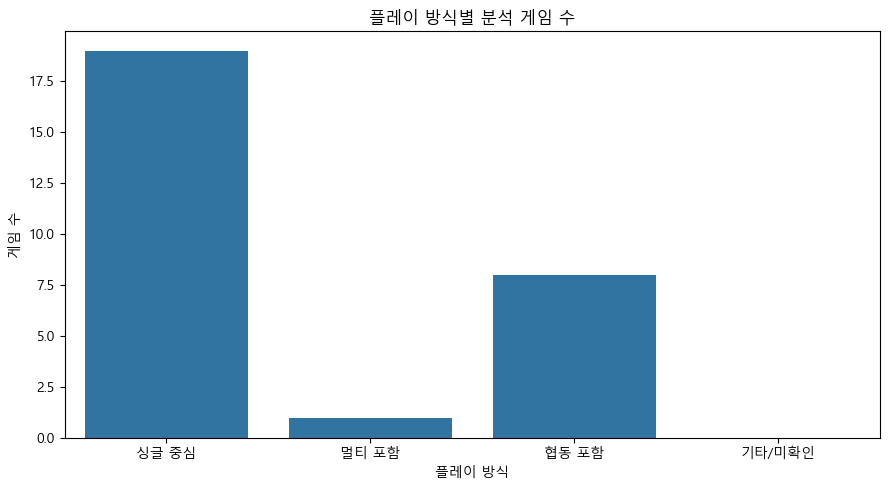

In [31]:
# ============================================================
# 14-0. 플레이 방식별 이슈 비교 공통 설정
# ============================================================
# play_mode_group 기준으로 긍정/부정 이슈를 비교한다.
# 값은 플레이 방식별 리뷰 수 대비 이슈 태그 비율이다.

issue_col = "issue_name_kor" if "issue_name_kor" in df_tag.columns else "tag_category"
positive_exclude_keywords = ["긍정 칭찬", "positive praise", "praise"]

play_mode_order = ["싱글 중심", "멀티 포함", "협동 포함", "기타/미확인"]

play_mode_review_count = (
    df_result
    .groupby("play_mode_group")["recommendationid"]
    .nunique()
    .reindex(play_mode_order)
)

play_mode_game_count = (
    df_result
    .drop_duplicates(["appid", "play_mode_group"])
    .groupby("play_mode_group")["appid"]
    .nunique()
    .reindex(play_mode_order)
)

play_mode_base_summary = pd.DataFrame({
    "리뷰수": play_mode_review_count,
    "게임수": play_mode_game_count,
}).reset_index().rename(columns={"play_mode_group": "플레이 방식"})

print("이슈명 컬럼:", issue_col)
print("[플레이 방식별 분석 표본]")
display(play_mode_base_summary)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=play_mode_base_summary,
    x="플레이 방식",
    y="게임수",
)
plt.title("플레이 방식별 분석 게임 수")
plt.xlabel("플레이 방식")
plt.ylabel("게임 수")
plt.tight_layout()
plt.show()


## 플레이 방식별 표본 확인

이 표와 그래프는 플레이 방식별로 몇 개의 게임과 리뷰가 포함되었는지 확인하기 위한 것이다.  
특정 플레이 방식의 게임 수가 적으면, 해당 결과는 참고용으로 해석하는 것이 안전하다.

**한줄 결과 설명:** 플레이 방식별 게임 수를 먼저 확인하여, 이후 이슈 비교 결과의 해석 범위를 점검하였다.


[플레이 방식별 주요 긍정 요소 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
play_mode_group,,,,,,,,,,
싱글 중심,0.7,1.7,0.8,8.9,6.1,0.3,2.7,1.9,0.8,1.9
멀티 포함,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
협동 포함,0.0,1.1,2.3,6.9,0.6,1.7,5.7,1.1,0.6,0.6
기타/미확인,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


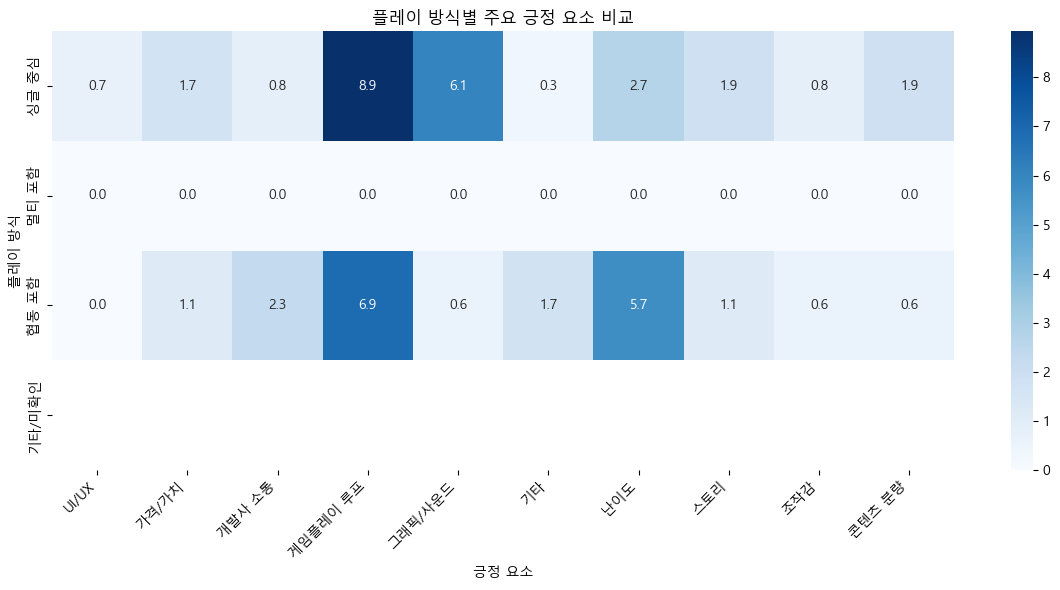

In [32]:
# ============================================================
# 14-1. 플레이 방식별 주요 긍정 요소 히트맵
# ============================================================
# 긍정 요소는 '긍정 칭찬'을 제외하고 본다.
# 값은 플레이 방식별 리뷰 수 대비 긍정 이슈 태그 비율이다.

play_positive = df_tag[
    (df_tag["tag_sentiment"] == "positive") &
    (df_tag["play_mode_group"].notna()) &
    (df_tag[issue_col].notna())
].copy()

# 전반적인 칭찬 태그 제외
play_positive = play_positive[
    ~play_positive[issue_col].astype(str).str.lower().isin(
        [word.lower() for word in positive_exclude_keywords]
    )
]

top_positive_issues = (
    play_positive[issue_col]
    .value_counts()
    .head(10)
    .index
)

play_positive_count = (
    play_positive[play_positive[issue_col].isin(top_positive_issues)]
    .groupby(["play_mode_group", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

play_positive_pivot_count = (
    play_positive_count
    .pivot_table(
        index="play_mode_group",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0,
    )
    .reindex(play_mode_order)
    .fillna(0)
)

play_positive_pivot_rate = play_positive_pivot_count.div(play_mode_review_count, axis=0) * 100

print("[플레이 방식별 주요 긍정 요소 비율(%)]")
display(play_positive_pivot_rate.round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(
    play_positive_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
)
plt.title("플레이 방식별 주요 긍정 요소 비교")
plt.xlabel("긍정 요소")
plt.ylabel("플레이 방식")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [33]:
# ============================================================
# 14-2. 플레이 방식별 긍정 요소 결과 요약
# ============================================================
# 각 플레이 방식에서 가장 비율이 높은 긍정 요소를 뽑아 요약한다.

play_positive_rows = []

for play_mode in play_mode_order:
    if play_mode not in play_positive_pivot_rate.index:
        continue

    row = play_positive_pivot_rate.loc[play_mode].dropna()

    if len(row) == 0 or row.sum() == 0:
        top_issue = "확인 어려움"
        top_rate = 0
    else:
        top_issue = row.idxmax()
        top_rate = row.max()

    play_positive_rows.append({
        "플레이 방식": play_mode,
        "주요 긍정 요소": top_issue,
        "리뷰 수 대비 비율(%)": round(top_rate, 1),
    })

play_positive_result_summary = pd.DataFrame(play_positive_rows)

print("[플레이 방식별 긍정 요소 요약]")
display(play_positive_result_summary)


[플레이 방식별 긍정 요소 요약]


,플레이 방식,주요 긍정 요소,리뷰 수 대비 비율(%)
0,싱글 중심,게임플레이 루프,8.9
1,멀티 포함,확인 어려움,0.0
2,협동 포함,게임플레이 루프,6.9
3,기타/미확인,확인 어려움,0.0


## 플레이 방식별 긍정 요소 결과 설명

이 히트맵은 플레이 방식별로 어떤 긍정 요소가 상대적으로 자주 나타나는지 보여준다.  
값은 플레이 방식별 리뷰 수 대비 긍정 이슈 태그 비율로 계산하였다.

`긍정 칭찬`은 전반적인 만족 표현에 가까우므로 제외하였다.  
이를 통해 싱글 중심 게임, 멀티 포함 게임, 협동 포함 게임에서 실제 강점으로 볼 수 있는 요소를 비교할 수 있다.

**한줄 결과 설명:** 플레이 방식별 긍정 요소는 각 플레이 방식에서 어떤 경험을 강점으로 강화해야 하는지 보여준다.


[플레이 방식별 주요 부정 이슈 비율(%)]


issue_name_kor,UI/UX,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,스토리,조작감,콘텐츠 분량
play_mode_group,,,,,,,,,,
싱글 중심,6.4,19.6,4.9,4.6,5.6,7.8,12.6,5.6,7.9,4.6
멀티 포함,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
협동 포함,10.3,22.9,4.6,2.9,13.7,8.6,9.7,0.0,12.0,5.7
기타/미확인,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


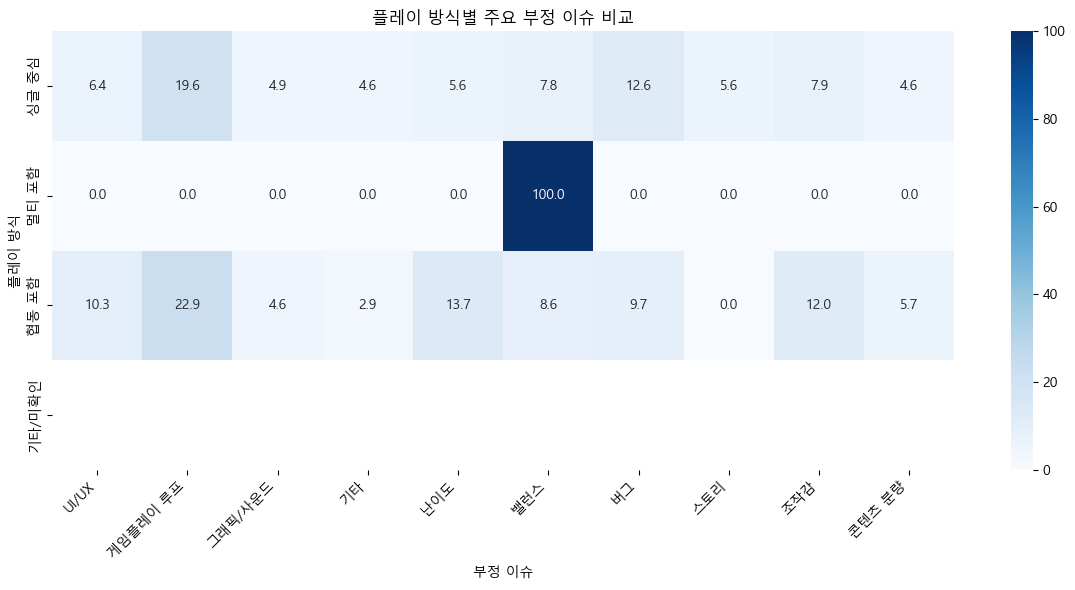

In [34]:
# ============================================================
# 14-3. 플레이 방식별 주요 부정 이슈 히트맵
# ============================================================
# 값은 플레이 방식별 리뷰 수 대비 부정 이슈 태그 비율이다.

play_negative = df_tag[
    (df_tag["tag_sentiment"] == "negative") &
    (df_tag["play_mode_group"].notna()) &
    (df_tag[issue_col].notna())
].copy()

top_negative_issues = (
    play_negative[issue_col]
    .value_counts()
    .head(10)
    .index
)

play_negative_count = (
    play_negative[play_negative[issue_col].isin(top_negative_issues)]
    .groupby(["play_mode_group", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

play_negative_pivot_count = (
    play_negative_count
    .pivot_table(
        index="play_mode_group",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0,
    )
    .reindex(play_mode_order)
    .fillna(0)
)

play_negative_pivot_rate = play_negative_pivot_count.div(play_mode_review_count, axis=0) * 100

print("[플레이 방식별 주요 부정 이슈 비율(%)]")
display(play_negative_pivot_rate.round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(
    play_negative_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
)
plt.title("플레이 방식별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("플레이 방식")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [35]:
# ============================================================
# 14-4. 플레이 방식별 부정 이슈 결과 요약
# ============================================================
# 각 플레이 방식에서 가장 비율이 높은 부정 이슈를 뽑아 요약한다.

play_negative_rows = []

for play_mode in play_mode_order:
    if play_mode not in play_negative_pivot_rate.index:
        continue

    row = play_negative_pivot_rate.loc[play_mode].dropna()

    if len(row) == 0 or row.sum() == 0:
        top_issue = "확인 어려움"
        top_rate = 0
    else:
        top_issue = row.idxmax()
        top_rate = row.max()

    play_negative_rows.append({
        "플레이 방식": play_mode,
        "주요 부정 이슈": top_issue,
        "리뷰 수 대비 비율(%)": round(top_rate, 1),
    })

play_negative_result_summary = pd.DataFrame(play_negative_rows)

print("[플레이 방식별 부정 이슈 요약]")
display(play_negative_result_summary)


[플레이 방식별 부정 이슈 요약]


,플레이 방식,주요 부정 이슈,리뷰 수 대비 비율(%)
0,싱글 중심,게임플레이 루프,19.6
1,멀티 포함,밸런스,100.0
2,협동 포함,게임플레이 루프,22.9
3,기타/미확인,확인 어려움,0.0


## 플레이 방식별 부정 이슈 결과 설명

이 히트맵은 플레이 방식별로 어떤 부정 이슈가 상대적으로 자주 나타나는지 보여준다.  
값은 플레이 방식별 리뷰 수 대비 부정 이슈 태그 비율로 계산하였다.

이를 통해 싱글 중심 게임에서는 콘텐츠 분량, 난이도, 게임플레이 루프 같은 요소가 중요하게 나타나는지,  
멀티 또는 협동 요소가 있는 게임에서는 밸런스, 조작감, UI/UX, 기술 안정성 같은 요소가 더 크게 나타나는지 확인할 수 있다.

**한줄 결과 설명:** 플레이 방식별 부정 이슈는 각 플레이 방식에서 출시 전 우선 점검해야 할 QA 리스크를 보여준다.


In [36]:
# ============================================================
# 14-5. 플레이 방식별 이슈 비교 최종 요약
# ============================================================
# 긍정 요소 요약과 부정 이슈 요약을 하나의 표로 합친다.

play_mode_issue_final_summary = play_positive_result_summary.merge(
    play_negative_result_summary,
    on="플레이 방식",
    how="outer",
)

print("[플레이 방식별 이슈 비교 최종 요약]")
display(play_mode_issue_final_summary)


[플레이 방식별 이슈 비교 최종 요약]


,플레이 방식,주요 긍정 요소,리뷰 수 대비 비율(%)_x,주요 부정 이슈,리뷰 수 대비 비율(%)_y
0,기타/미확인,확인 어려움,0.0,확인 어려움,0.0
1,멀티 포함,확인 어려움,0.0,밸런스,100.0
2,싱글 중심,게임플레이 루프,8.9,게임플레이 루프,19.6
3,협동 포함,게임플레이 루프,6.9,게임플레이 루프,22.9


## 플레이 방식별 이슈 비교 결과 요약

플레이 방식별 분석에서는 싱글, 멀티, 협동 여부에 따라 유저가 만족하는 요소와 불만을 느끼는 요소가 달라지는지 확인하였다.  
긍정 요소는 각 플레이 방식의 강점 후보를 보여주고, 부정 이슈는 출시 전 QA에서 우선 점검해야 할 리스크를 보여준다.

**최종 요약:** 플레이 방식별 이슈 비교는 싱글/멀티/협동 여부에 따라 출시 전 체크리스트와 개발 우선순위를 다르게 설계해야 함을 보여주는 분석이다.


# 15. 출시 전 점검 항목 도출

LLM 분석에서 반복적으로 확인된 긍정·부정 요소를 바탕으로, Action 장르 인디게임 개발자가 출시 전 단계에서 점검해야 할 항목을 정리한다.

| 점검 영역          | 점검 질문                                    | 관련 이슈                   | 권장 대응                                |
| -------------- | ---------------------------------------- | ----------------------- | ------------------------------------ |
| 핵심 플레이 루프      | 전투, 이동, 반복 플레이 구조가 짧은 시간 안에도 재미있게 전달되는가? | 게임플레이 루프                | 프로토타입/데모 단계에서 핵심 루프 반복 테스트를 우선 진행    |
| 조작감            | 입력 반응, 카메라, 이동 방식, 키 설정이 불편하지 않은가?       | 조작감                     | 조작 튜토리얼, 키 리바인딩, 카메라 옵션, 피드백 효과 점검   |
| UI/UX와 초반 안내   | 초반 목표, 메뉴, 인벤토리, 튜토리얼이 직관적으로 안내되는가?      | UI/UX                   | 첫 10~30분 플레이 구간에서 목표 안내와 메뉴 접근성 테스트  |
| 난이도와 밸런스       | 초반 난이도가 과도하거나, 특정 구간에서 불합리하게 느껴지지 않는가?   | 난이도, 밸런스                | 난이도 곡선과 실패 후 재도전 경험을 별도 점검           |
| 버그와 기술 안정성     | 진행 불가, 저장 오류, 크래시, 성능 저하 문제가 없는가?        | 버그, 크래시, 저장/진행, 성능, 최적화 | 출시 직전 QA에서 진행 불가/크래시/저장 문제를 우선 점검    |
| 콘텐츠 밀도와 반복 피로도 | 출시 초기에 충분한 콘텐츠와 반복 플레이 동기가 있는가?          | 콘텐츠 분량, 성장/반복 노가다       | 반복 플레이 동기, 보상 구조, 콘텐츠 소모 속도 점검       |
| 그래픽/사운드와 분위기   | 타격감, 사운드, 분위기, 시각적 피드백이 장르 기대치에 맞는가?     | 그래픽/사운드                 | 액션 피드백, 효과음, 분위기 연출을 출시 전 데모 반응으로 검증 |
| 가격 대비 가치       | 가격대에 비해 제공되는 콘텐츠와 완성도가 납득 가능한가?          | 가격/가치, 콘텐츠 분량           | 유사 게임 가격대와 콘텐츠 분량을 함께 비교해 출시 가격 검토   |


# 16. 핵심 인사이트

## 인사이트 1. Action 장르 유저는 핵심 플레이 루프를 가장 중요하게 평가한다

게임플레이 루프는 긍정과 부정 양쪽에서 모두 강하게 나타난 평가 축이다.  
전투, 이동, 반복 플레이 구조, 조작의 손맛이 잘 전달되면 강점이 되지만, 반대로 루프가 단조롭거나 불편하면 부정 리뷰로 이어질 수 있다.

따라서 Action 인디게임 개발자는 출시 전 단계에서 핵심 플레이가 짧은 시간 안에 충분히 전달되는지 우선 점검해야 한다.

## 인사이트 2. 조작감, UI/UX, 난이도는 출시 초기 부정 반응의 주요 리스크다

부정 태그 상위에는 조작감, UI/UX, 밸런스, 난이도가 반복적으로 등장했다.  
이는 게임 아이디어가 좋더라도 초반 조작 안내가 부족하거나 난이도 적응이 어렵다면, 출시 직후 부정 반응으로 이어질 수 있음을 의미한다.

## 인사이트 3. 가격대별 분석은 가격 대비 기대치를 점검하는 데 활용할 수 있다

가격대별 비교를 통해 특정 가격대에서 부정 리뷰 비율, High 시급도 비율, 주요 부정 이슈가 어떻게 달라지는지 확인하였다.  
출시 가격이 높을수록 유저는 콘텐츠 분량, 완성도, 기술 안정성에 더 민감하게 반응할 수 있으므로, 가격 전략은 단순 가격 비교가 아니라 기대 품질 기준과 함께 검토해야 한다.

## 인사이트 4. Steam 태그별 분석은 세부 게임 유형별 리스크를 나누는 데 도움이 된다

같은 Action 장르라도 Steam 태그에 따라 유저가 기대하는 플레이 경험은 달라진다.  
따라서 태그별 반복 이슈를 확인하면 Roguelike, RPG, Exploration, First-Person 같은 세부 유형별로 개발 우선순위와 체크리스트를 다르게 설계할 수 있다.

## 인사이트 5. 플레이 방식별 분석은 QA 체크리스트를 세분화하는 데 유용하다

싱글 중심 게임과 협동/멀티 요소가 있는 게임은 유저가 불편하게 느끼는 지점이 다를 수 있다.  
싱글 중심 게임은 초반 진행 경험, 콘텐츠 밀도, 난이도 흐름을 중점적으로 보고, 협동/멀티 요소가 있는 게임은 밸런스, UI/UX, 기술 안정성, 협동 흐름을 더 우선적으로 점검해야 한다.


# 17. 적용한 추가 분석 요약

기존 보고서는 LLM이 분류한 감정, 이슈 태그, 개선 시급도를 중심으로 Action 장르의 공통적인 유저 반응을 정리하였다.

이번 버전에서는 여기서 한 단계 더 나아가, LLM 결과를 게임 속성 정보와 연결해 다음 세 가지 비교 분석을 추가하였다.

| 추가 분석 | 확인한 내용 | 활용 방향 |
|---|---|---|
| 가격대별 이슈 비교 | 가격대에 따라 부정 리뷰 비율, High 시급도 비율, 주요 부정 이슈가 달라지는지 확인 | 출시 가격과 기대 품질 기준 설정 |
| Steam 태그별 이슈 비교 | 세부 태그별로 반복되는 부정 이슈 확인 | 태그 조합별 개발 우선순위 설정 |
| 플레이 방식별 이슈 비교 | 싱글/멀티/협동 여부에 따른 불만 요인 비교 | 플레이 방식별 QA 체크리스트 설계 |

이를 통해 단순히 “어떤 이슈가 많이 나왔는가”에서 끝나지 않고, **어떤 게임 속성에서 어떤 리스크가 반복되는가**까지 확인할 수 있도록 분석을 확장하였다.


# 18. 분석 한계 및 최종 정리

## 분석 한계

본 분석은 Steam 전체 Action 장르 게임 전체가 아니라, LLM 분석 대상으로 선별된 리뷰 표본을 기준으로 한다.  
따라서 긍정률, 부정 이슈 비율, High urgency 비율은 전체 시장의 절대값이 아니라 표본 안에서 확인된 경향으로 해석해야 한다.

또한 이번 결과는 770개 리뷰를 기반으로 한 v2 분석이다.  
튜터 피드백 기준으로 가능한 많은 리뷰를 분석하는 것이 바람직하지만, 리뷰 수를 더 늘릴 경우 일부 리뷰 수가 많은 게임의 비중이 커지는 문제가 확인되었다.  
따라서 본 보고서에서는 장르 전체 경향을 해석하기 위해 v2 결과를 최종 기준으로 사용하였다.

가격대별, Steam 태그별, 플레이 방식별 분석은 출시 전 전략과 연결하기 위한 확장 분석이다.  
다만 각 그룹의 표본 수가 다를 수 있으므로, 단순 태그 수뿐 아니라 리뷰 수 대비 비율을 함께 확인해야 한다.

마지막으로 LLM이 생성한 `urgency`, `summary`, `suggested_action`, `issue_tags`는 리뷰 문맥을 기반으로 한 해석 결과이므로, 실제 장애 지표나 정답 라벨이 아니다.  
따라서 이 결과는 최종 판단이 아니라 출시 전 점검을 돕는 참고 자료로 활용하는 것이 적절하다.

## 최종 정리

이번 출시 전 분석은 Action 장르 유사 게임의 D0-D30 초기 리뷰를 LLM으로 분석하여, 유저가 긍정적으로 평가한 요소와 불만을 가진 요소를 정리하였다.

기본 분석에서는 게임플레이 루프, 조작감, UI/UX, 난이도, 밸런스, 버그 및 기술 안정성이 핵심 평가 요소로 나타났다.  
확장 분석에서는 이를 가격대, Steam 태그, 플레이 방식 기준으로 다시 비교하여 출시 전 전략에 더 직접적으로 연결하였다.

최종적으로 이 분석은 Action 장르 게임을 출시하려는 개발자가 출시 전 단계에서 무엇을 우선적으로 점검해야 하는지 정리하는 체크리스트와 개발 우선순위 제안으로 활용할 수 있다.


# 부록. 보고서 작성용 핵심 값 확인

아래 셀은 팀 노션이나 최종 보고서에 문장을 작성하기 전에 확인하는 요약 자료다.  
경로가 v2 결과 폴더를 바라보고 있는지 먼저 확인한 뒤 실행한다.


In [37]:
# ============================================================
# 부록. 보고서 작성용 핵심 값 확인
# ============================================================

report_values = pd.DataFrame({
    "항목": [
        "최종 분석 리뷰 수",
        "최종 분석 게임 수",
        "Steam 긍정 리뷰 수",
        "Steam 부정 리뷰 수",
        "LLM 긍정 리뷰 수",
        "LLM 부정 리뷰 수",
        "LLM 혼합 리뷰 수",
        "High urgency 리뷰 수",
        "Steam-LLM exact_match 수",
        "Steam-LLM partial_match 수",
        "이슈 태그 수",
        "이슈 태그 없는 리뷰 수",
    ],
    "값": [
        len(df_result),
        df_result["appid"].nunique(),
        (df_result["steam_label_text"] == "positive").sum(),
        (df_result["steam_label_text"] == "negative").sum(),
        (df_result["llm_sentiment"] == "positive").sum(),
        (df_result["llm_sentiment"] == "negative").sum(),
        (df_result["llm_sentiment"] == "mixed").sum(),
        (df_result["urgency"] == "high").sum(),
        (df_result["sentiment_relation"] == "exact_match").sum(),
        (df_result["sentiment_relation"] == "partial_match").sum(),
        len(df_tag),
        len(reviews_without_tags),
    ]
})

display(report_values)

,항목,값
0,최종 분석 리뷰 수,770
1,최종 분석 게임 수,28
2,Steam 긍정 리뷰 수,511
3,Steam 부정 리뷰 수,259
4,LLM 긍정 리뷰 수,465
5,LLM 부정 리뷰 수,241
6,LLM 혼합 리뷰 수,58
7,High urgency 리뷰 수,214
8,Steam-LLM exact_match 수,704
9,Steam-LLM partial_match 수,58
